# Position and Direction model Training

Position and direction reconstruction training pipeline for the SBND detector.
Uses a reduced ResNet-18 architecture (~3M parameters) to predict neutrino vertex
position (X, Y, Z) and direction (dirY, dirZ) from PMT light images.


## 1. Setup and Configuration

### GPU and system check
Detect available GPUs and enable memory growth so TensorFlow allocates GPU RAM on demand instead of reserving all of it at once. This prevents out-of-memory errors when sharing the GPU with other processes. Also prints available CPU RAM as a sanity check before loading data.

In [1]:
import os, psutil
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

print("GPU:", gpus)
print(f"RAM libre: {psutil.virtual_memory().available/1e9:.1f} GB")

2026-04-19 21:57:55.966001: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-19 21:57:55.966114: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-19 21:57:55.967782: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-19 21:57:55.972792: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
RAM libre: 478.0 GB


2026-04-19 21:58:04.228536: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-19 21:58:04.265857: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-19 21:58:04.266219: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### Import all required libraries
Load every Python package used throughout the notebook:
- **numpy / pandas** — numerical arrays and tabular data
- **uproot / awkward** — read ROOT files (the LArSoft output format) without ROOT
- **matplotlib / scipy** — plotting and Gaussian curve fitting
- **sklearn** — train/val/test splitting utilities
- **TensorFlow / Keras** — model definition, training, and callbacks

TensorFlow C++ log messages are suppressed to keep the output clean.

In [2]:
import sys
sys.path.insert(0, '/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/NuIntNNOpReco/2-cnn-training-notebooks/')
import importlib, plot_style
importlib.reload(plot_style)
from plot_style import *

import os, time as _t, gc
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split

# Suppress TF C++ logs before importing TF (0=all, 1=no INFO, 2=no WARNING, 3=no ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import random


### Coordinate normalization utilities
Define the physical detector boundaries for SBND (in cm) and the target normalized ranges for the network outputs (X, Z → [0, 1]; Y → [-1, 1]).

Using *detector-boundary* normalization instead of data-driven normalization is important: it keeps the scale fixed regardless of the event distribution, which avoids biasing the model towards densely populated regions. The helper functions `minmax_normalize` and `minmax_denormalize` convert between physical cm and normalized units and will be reused during evaluation.

In [3]:
# ── Physical coordinate ranges and normalization ───────────────────────────
# Fixed detector boundaries ensure normalization is independent of the
# data distribution, avoiding bias from non-uniform event distributions.
PHYS_RANGES = {'x': (0., 200.), 'y': (-200., 200.), 'z': (0., 500.)}
# Target normalization ranges per axis: X,Z -> [0, 1]; Y -> [-1, 1]
TARGET_RANGES = {'x': (0., 1.), 'y': (-1., 1.), 'z': (0., 1.)}
COORD_CONFIG = {'ranges': PHYS_RANGES, 'target_ranges': TARGET_RANGES}  # stored for evaluation and export

def minmax_normalize(coords, ranges=PHYS_RANGES, target_ranges=TARGET_RANGES):
    """Normalize coordinates from physical cm to per-axis target range.
    X,Z -> [0, 1], Y -> [-1, 1]."""
    result = np.empty_like(coords, dtype=np.float32)
    for i, key in enumerate(['x', 'y', 'z']):
        lo, hi = ranges[key]
        tlo, thi = target_ranges[key]
        result[:, i] = (coords[:, i] - lo) / (hi - lo) * (thi - tlo) + tlo
    return result

def minmax_denormalize(coords_norm, ranges=PHYS_RANGES, target_ranges=TARGET_RANGES):
    """Inverse of minmax_normalize: per-axis target range back to physical cm."""
    result = np.empty_like(coords_norm, dtype=np.float32)
    for i, key in enumerate(['x', 'y', 'z']):
        lo, hi = ranges[key]
        tlo, thi = target_ranges[key]
        result[:, i] = (coords_norm[:, i] - tlo) / (thi - tlo) * (hi - lo) + lo
    return result

print(f'   * Physical ranges: {PHYS_RANGES}')
print(f'   * Target ranges:   {TARGET_RANGES}')


   * Physical ranges: {'x': (0.0, 200.0), 'y': (-200.0, 200.0), 'z': (0.0, 500.0)}
   * Target ranges:   {'x': (0.0, 1.0), 'y': (-1.0, 1.0), 'z': (0.0, 1.0)}


### Create a timestamped output directory
All plots, trained model weights and metadata produced during this run are saved under a unique folder named with the current date and time (e.g. `run_20241010_1430`). This prevents accidentally overwriting results from previous training runs.

In [6]:
# ── Output directory (new folder per run) ───────────────────────────
from datetime import datetime
_ts = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_' + _ts
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'>> Output directory: {SAVE_DIR}')

>> Output directory: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158


### Fix random seeds for reproducibility
Set the same integer seed for Python's `random`, NumPy, and TensorFlow. This ensures that the train/val/test split, weight initialization, and data shuffling are identical across runs, making results fully reproducible.

In [7]:
# ── Random seeds ─────────────────────────────────────────────────────────────
import random
import numpy as np
import tensorflow as tf

SEED = 777
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"   * Random seeds set (numpy, tf, random) = {SEED}")


   * Random seeds set (numpy, tf, random) = 777


### Load data from ROOT file
This is the main data-loading cell — it performs three steps in order:

1. **Labels**: read reconstructed quantities (energy-weighted barycenter `dEprom`, principal direction `dEdir`, spread `dEspread`, PCA eigenvalues) and the `passed_filters` / `selected_tpc` flags. Only events that passed all analysis filters are kept.

2. **Train/val/test split** (70 / 15 / 15 %): the split is computed *before* loading the images so that the normalization factor is derived from the training set only, preventing **data leakage** from validation/test events.

3. **Images**: the two-channel PE images (uncoated PMTs + coated PMTs, shape `[events, ny, nz, 2]`) are loaded in batches and divided by the training-set maximum to normalize them to [0, 1].

In [8]:
ROOT_FILE = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/MC_entire_sample_FallProd/FallProd/FallProd_complete_dataset_v1603.root'

_t0 = _t.time()
print('Loading ROOT file...')
f_root = uproot.open(ROOT_FILE)

# ── 1. Labels ─────────────────────────────────────────────────────
lab = f_root['dataprep/labels/tree'].arrays(
    ['passed_filters', 'selected_tpc',
     'dEprom_x',  'dEprom_y',  'dEprom_z',
     'dEdir_x',   'dEdir_y',   'dEdir_z',
     'dEspread_x','dEspread_y','dEspread_z',
     'dEpca_lam1','dEpca_lam2','dEpca_lam3'], library='ak')

ok   = np.array(lab['passed_filters'], dtype=bool)
stpc = np.array(lab['selected_tpc'],   dtype=np.int32)
print(f'  passed_filters: {ok.sum():,} / {len(ok):,}  ({_t.time()-_t0:.1f}s)')

stpc_ok = stpc[ok]

def get_tpc_label(arr_ak, ok_mask, tpc_idx):
    ok_list = ak.to_list(arr_ak[ok_mask])
    return np.array([row[t] for row, t in zip(ok_list, tpc_idx)], dtype=np.float32)

dEpromx_final = get_tpc_label(lab['dEprom_x'],   ok, stpc_ok)
dEpromy_final = get_tpc_label(lab['dEprom_y'],   ok, stpc_ok)
dEpromz_final = get_tpc_label(lab['dEprom_z'],   ok, stpc_ok)
dEdirx        = get_tpc_label(lab['dEdir_x'],    ok, stpc_ok)
dEdiry        = get_tpc_label(lab['dEdir_y'],    ok, stpc_ok)
dEdirz        = get_tpc_label(lab['dEdir_z'],    ok, stpc_ok)
dEspreadx     = get_tpc_label(lab['dEspread_x'], ok, stpc_ok)
dEspready     = get_tpc_label(lab['dEspread_y'], ok, stpc_ok)
dEspreadz     = get_tpc_label(lab['dEspread_z'], ok, stpc_ok)
dEpca_lam1    = get_tpc_label(lab['dEpca_lam1'], ok, stpc_ok)
dEpca_lam2    = get_tpc_label(lab['dEpca_lam2'], ok, stpc_ok)
dEpca_lam3    = get_tpc_label(lab['dEpca_lam3'], ok, stpc_ok)
del lab
print(f'  Labels extracted: {len(dEpromx_final):,} events  ({_t.time()-_t0:.1f}s)')

# ── 2. Image grid dimensions and train/val/test split indices ─────────────────
# The split is computed HERE (before loading images) so that the normalization
# factor is derived exclusively from the training set — avoiding data leakage.
mx = f_root['dataprep/images/tree'].arrays(
    ['max_pe_uncoated', 'max_pe_coated', 'image_ny', 'image_nz'],
    entry_stop=int(ok.size), library='np')
ny = int(mx['image_ny'][ok][0])
nz = int(mx['image_nz'][ok][0])
n_ok = int(ok.sum())

# Early split on event indices (70 / 15 / 15)
from sklearn.model_selection import train_test_split as _tts
_idx_all = np.arange(n_ok)
idx_tr,  _idx_tmp = _tts(_idx_all, test_size=0.30, random_state=SEED)
idx_val, idx_te   = _tts(_idx_tmp, test_size=0.50, random_state=SEED)
idx_tr.sort(); idx_val.sort(); idx_te.sort()
print(f'  Split: train={len(idx_tr):,}  val={len(idx_val):,}  test={len(idx_te):,}')

# Normalization: p99.9 clip per channel, then joint max
# Using p99.9 instead of absolute max to avoid a single outlier event
# (coated max=895k vs p99.9=42k) compressing the dynamic range of all images.
train_max_u = float(np.percentile(mx['max_pe_uncoated'][ok][idx_tr], 99.9))
train_max_c = float(np.percentile(mx['max_pe_coated'][ok][idx_tr],   99.9))
train_max   = max(train_max_u, train_max_c)  # joint clip — matches inference module
del mx
print(f'  Train-set max PE — uncoated: {train_max_u:.1f}, coated: {train_max_c:.1f}')
print(f'  Joint normalisation factor  : {train_max:.1f}  ({_t.time()-_t0:.1f}s)')

# ── 3. Images — single pass, batched, joint-max norm, float32 ──────────────────
BATCH = 50_000
print(f'  Image grid: {ny} x {nz},  ok events: {n_ok:,}')
print(f'  Memory for images (float32): {n_ok*ny*nz*2*4/1e9:.2f} GB')

images   = np.empty((n_ok, ny, nz, 2), dtype=np.float32)
ev_start = 0
out_idx  = 0
for chunk in f_root['dataprep/images/tree'].iterate(
        ['image_uncoated', 'image_coated'], step_size=BATCH, library='ak'):
    n_chunk    = len(chunk['image_uncoated'])
    ok_chunk   = ok[ev_start:ev_start + n_chunk]
    n_ok_chunk = int(ok_chunk.sum())
    if n_ok_chunk > 0:
        u = ak.to_numpy(chunk['image_uncoated'][ok_chunk]).reshape(n_ok_chunk, ny, nz)
        c = ak.to_numpy(chunk['image_coated'][ok_chunk]).reshape(n_ok_chunk, ny, nz)
        images[out_idx:out_idx+n_ok_chunk, :, :, 0] = np.clip(u / train_max, 0, 1).astype(np.float32)
        images[out_idx:out_idx+n_ok_chunk, :, :, 1] = np.clip(c / train_max, 0, 1).astype(np.float32)
        del u, c
        out_idx += n_ok_chunk
    ev_start += n_chunk
    print(f'  {ev_start:,}/{ok.size}  ({out_idx:,} ok)  ({_t.time()-_t0:.1f}s)', end='\r')

gc.collect()
normalization_factor = train_max  # single joint factor (same for both channels)
print(f'\n  Images: {images.shape}  dtype={images.dtype}  ({_t.time()-_t0:.1f}s)')
print(f'\nTotal events loaded: {len(images):,}  —  {_t.time()-_t0:.1f}s')


Loading ROOT file...


  passed_filters: 554,528 / 1,365,732  (12.4s)
  Labels extracted: 554,528 events  (28.1s)
  Split: train=388,169  val=83,179  test=83,180
  Train-set max PE — uncoated: 1368.1, coated: 42043.7
  Joint normalisation factor  : 42043.7  (31.5s)
  Image grid: 59 x 70,  ok events: 554,528
  Memory for images (float32): 18.32 GB
  1,365,732/1365732  (554,528 ok)  (212.8s)
  Images: (554528, 59, 70, 2)  dtype=float32  (213.1s)

Total events loaded: 554,528  —  213.1s


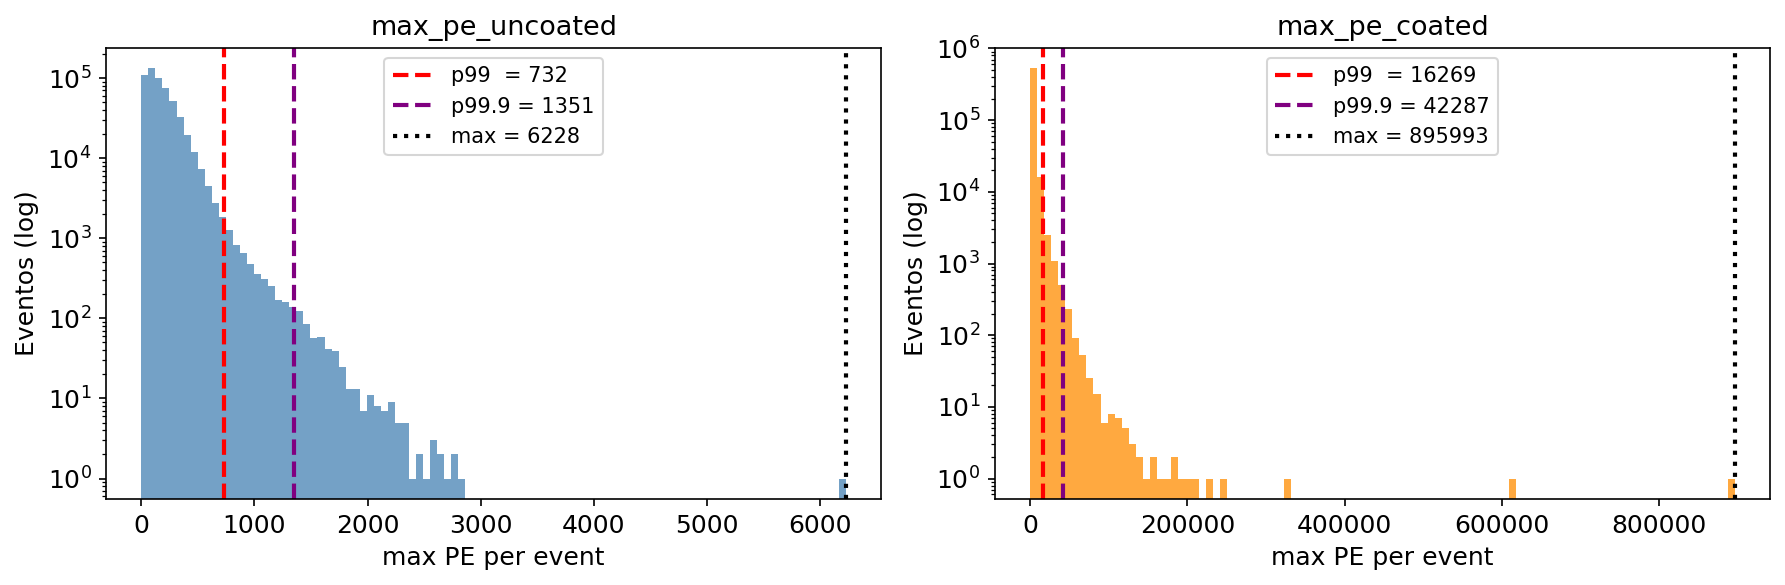

uncoated -- mean=184.0  median=145.1  p99=732.0  p99.9=1351.4  max=6228.5
coated   -- mean=2329.9  median=1182.0  p99=16269.2  p99.9=42286.7  max=895992.6


In [9]:
# -- Histograma de max_pe_uncoated y max_pe_coated
mx2 = f_root['dataprep/images/tree'].arrays(['max_pe_uncoated', 'max_pe_coated'],
                                             entry_stop=int(ok.size), library='np')
max_u_all = mx2['max_pe_uncoated'][ok]
max_c_all = mx2['max_pe_coated'][ok]
del mx2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, vals, label, color in zip(
        axes,
        [max_u_all, max_c_all],
        ['max_pe_uncoated', 'max_pe_coated'],
        ['steelblue', 'darkorange']):
    p99  = np.percentile(vals, 99)
    p999 = np.percentile(vals, 99.9)
    ax.hist(vals, bins=100, color=color, alpha=0.75, log=True)
    ax.axvline(p99,  color='red',    linestyle='--', label=f'p99  = {p99:.0f}')
    ax.axvline(p999, color='purple', linestyle='--', label=f'p99.9 = {p999:.0f}')
    ax.axvline(vals.max(), color='black', linestyle=':', label=f'max = {vals.max():.0f}')
    ax.set_xlabel('max PE per event', fontsize=12)
    ax.set_ylabel('Eventos (log)', fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'hist_max_pe.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(SAVE_DIR, 'hist_max_pe.pdf'), bbox_inches='tight')
plt.show()
print(f'uncoated -- mean={max_u_all.mean():.1f}  median={np.median(max_u_all):.1f}  '
      f'p99={np.percentile(max_u_all,99):.1f}  p99.9={np.percentile(max_u_all,99.9):.1f}  max={max_u_all.max():.1f}')
print(f'coated   -- mean={max_c_all.mean():.1f}  median={np.median(max_c_all):.1f}  '
      f'p99={np.percentile(max_c_all,99):.1f}  p99.9={np.percentile(max_c_all,99.9):.1f}  max={max_c_all.max():.1f}')


### Visualize example PE images
Plot the uncoated and coated PMT images for a randomly chosen event to verify that the data was loaded and normalized correctly. The images show the photoelectron (PE) count collected by each PMT as a 2D map (channel index vs position). Examining a few examples before training helps spot obvious data problems.

>> Example event #185843
   * Position: X=73.1 cm, Y=77.0 cm, Z=154.3 cm


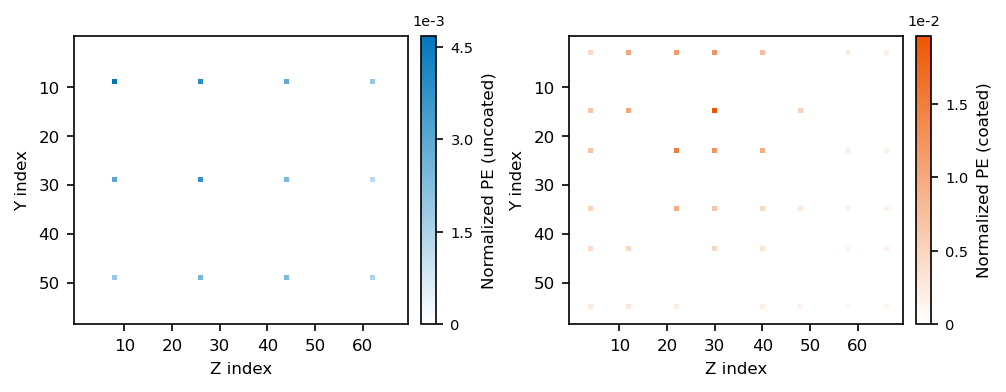


>> Image statistics:
   * Shape: (59, 70, 2)
   * Channel 0 (Uncoated): min=0.0000, max=0.0047, mean=0.0000
   * Channel 1 (Coated):   min=0.0000, max=0.0197, mean=0.0001
   * Non-zero pixels: 50 / 8260 (0.6%)


In [10]:
# Visualize example PE images for a random event
import math, colorsys
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

def saturate(color, factor=1.8):
    """Boost saturation (HSV) keeping hue and value."""
    r, g, b, _ = mcolors.to_rgba(color)
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    return colorsys.hsv_to_rgb(h, min(1.0, s * factor), v)

cmap_u = LinearSegmentedColormap.from_list('uncoated', ['white', saturate(C_PRIMARY)])
cmap_c = LinearSegmentedColormap.from_list('coated',   ['white', saturate(C_SECONDARY)])

def nice_vmax(v):
    if v == 0: return 1
    mag = 10 ** math.floor(math.log10(v))
    return math.ceil(v / (mag / 2)) * (mag / 2)

# p99.5 de PMTs activos
nonzero_count = (images[:, :, :, 1] > 0).sum(axis=(1,2))
event_idx = int(np.argsort(nonzero_count)[int(0.995 * len(nonzero_count))])
print(f'>> Example event #{event_idx}')
print(f'   * Position: X={dEpromx_final[event_idx]:.1f} cm, Y={dEpromy_final[event_idx]:.1f} cm, Z={dEpromz_final[event_idx]:.1f} cm')

img = images[event_idx]  # Shape: (59, 70, 2)

img_u = np.ma.masked_where(img[:, :, 0] == 0, img[:, :, 0])
img_c = np.ma.masked_where(img[:, :, 1] == 0, img[:, :, 1])

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.5), constrained_layout=True)

for ax, data, cmap, label in zip(
        axes,
        [img_u, img_c],
        [cmap_u, cmap_c],
        ['Normalized PE (uncoated)', 'Normalized PE (coated)']):
    im = ax.imshow(data, cmap=cmap, aspect='auto', origin='upper', vmin=0)
    ax.set_xticks([10, 20, 30, 40, 50, 60])
    ax.set_yticks([10, 20, 30, 40, 50])
    ax.set_xlabel('Z index', fontsize=8)
    ax.set_ylabel('Y index', fontsize=8)
    ax.tick_params(labelsize=8)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(label, fontsize=8)
    cb.locator = MaxNLocator(nbins=4, min_n_ticks=3)
    dmax = float(data.max())
    exp = int(math.floor(math.log10(dmax))) if dmax > 0 else 0
    cb.formatter = FuncFormatter(lambda x, _, e=exp: f'{x/10**e:.1f}' if x != 0 else '0')
    cb.update_ticks()
    cb.ax.tick_params(labelsize=7)
    cb.ax.set_title(f'1e{exp:d}', fontsize=7, pad=5)

plt.savefig(f'{SAVE_DIR}/pe_images_example.png', dpi=500, bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}/pe_images_example.pdf', bbox_inches='tight')
plt.show()

print(f'\n>> Image statistics:')
print(f'   * Shape: {img.shape}')
print(f'   * Channel 0 (Uncoated): min={img[:,:,0].min():.4f}, max={img[:,:,0].max():.4f}, mean={img[:,:,0].mean():.4f}')
print(f'   * Channel 1 (Coated):   min={img[:,:,1].min():.4f}, max={img[:,:,1].max():.4f}, mean={img[:,:,1].mean():.4f}')
print(f'   * Non-zero pixels: {np.count_nonzero(img)} / {img.size} ({100*np.count_nonzero(img)/img.size:.1f}%)')

## 4. Target Variable Preparation

### Prepare position target variables
Extract the three position coordinates (X, Y, Z) of the energy-weighted barycenter (`dEprom`) and stack them into a single array. The X coordinate is taken as its **absolute value** because the two TPCs are mirror-symmetric about X = 0 (except for the off-PMTs), so both TPCs are mapped onto the same positive half-space. This lets a single model cover both TPCs without needing separate networks.

In [11]:
# Prepare coordinates (use absolute x)
print(">> Preparing target variables...")

# Baricentro (dEprom)
x_abs = np.abs(np.array(dEpromx_final).flatten())
y = np.array(dEpromy_final).flatten()
z = np.array(dEpromz_final).flatten()

coordinates = np.column_stack((x_abs, y, z))
print(f"   * Coordinate ranges before standardization:")
print(f"     - X (abs): [{np.min(x_abs):.1f}, {np.max(x_abs):.1f}]")
print(f"     - Y: [{np.min(y):.1f}, {np.max(y):.1f}]")
print(f"     - Z: [{np.min(z):.1f}, {np.max(z):.1f}]")

# NOTE: min-max normalization with physical detector ranges is applied after
#       the train/val/test split (cell 12). Here we just store raw coordinates.
y_pos_raw = coordinates.copy()
print(f"\n   * Raw coordinates stored (standardization after split)")
print(f"   * Position target shape: {y_pos_raw.shape}")

# ========================================================================
# TARGET 2: Direction 2D in YZ plane (y_dir) - shape (N, 2)
# ========================================================================
dirx = np.array(dEdirx).flatten()
diry = np.array(dEdiry).flatten()
dirz = np.array(dEdirz).flatten()

print(f"\n   * PCA Direction 3D ranges:")
print(f"     - dirx: [{np.nanmin(dirx):.3f}, {np.nanmax(dirx):.3f}]")
print(f"     - diry: [{np.nanmin(diry):.3f}, {np.nanmax(diry):.3f}]")
print(f"     - dirz: [{np.nanmin(dirz):.3f}, {np.nanmax(dirz):.3f}]")

# Project onto YZ plane and normalize
# norm_yz_safe avoids division by zero for rare events nearly parallel to X axis;
# those events are kept in the dataset (w_dir will naturally down-weight them).
norm_yz = np.sqrt(diry**2 + dirz**2)
norm_yz_safe = np.maximum(norm_yz, 1e-6)
dir2d_y = diry / norm_yz_safe
dir2d_z = dirz / norm_yz_safe

y_dir = np.column_stack((dir2d_y, dir2d_z))  # (N, 2)

print(f"\n   * Direction 2D target (YZ plane):")
print(f"     - dir2d_y: [{np.min(dir2d_y):.3f}, {np.max(dir2d_y):.3f}]")
print(f"     - dir2d_z: [{np.min(dir2d_z):.3f}, {np.max(dir2d_z):.3f}]")

# Diagnostic: how many events are nearly parallel to X axis
n_degenerate = np.sum(norm_yz < 0.1)
print(f"\n   * Events with norm_yz < 0.1 (nearly along X): {n_degenerate} ({100*np.mean(norm_yz < 0.1):.2f}%) — kept")

# Filter only truly invalid values (-999 or NaN), not near-X-axis events
invalid_mask = (dirx == -999) | (diry == -999) | (dirz == -999) | \
               np.isnan(dirx) | np.isnan(diry) | np.isnan(dirz)
good_mask = ~invalid_mask
n_removed = int(np.sum(invalid_mask))
if n_removed > 0:
    print(f"\n   * Filtering {n_removed} invalid events (-999/NaN)...")
    y_pos_raw  = y_pos_raw[good_mask]
    y_dir      = y_dir[good_mask]
    images     = images[good_mask]
    # The split indices (idx_tr/val/te) were computed in the data-loading cell on
    # n_ok events. If events were removed here, those indices are stale — recompute.
    from sklearn.model_selection import train_test_split as _tts2
    _n_filtered = len(images)
    idx_tr,  _idx_tmp2 = _tts2(np.arange(_n_filtered), test_size=0.30, random_state=SEED)
    idx_val, idx_te    = _tts2(_idx_tmp2, test_size=0.50, random_state=SEED)
    idx_tr.sort(); idx_val.sort(); idx_te.sort()
    print(f"   * Remaining events: {_n_filtered:,}  — split recomputed")
else:
    print(f"\n   * No invalid events found — split indices unchanged")

# ========================================================================
# WEIGHT: Directionality from PCA eigenvalues (lam1 >= lam2 >= lam3)
# w_dir = lam1 / (lam1 + lam2 + lam3): fraction of variance along main axis
# Range: [1/3 isotropic shower] → [1 perfect track]
# ========================================================================
lam1 = np.array(dEpca_lam1).flatten()
lam2 = np.array(dEpca_lam2).flatten()
lam3 = np.array(dEpca_lam3).flatten()

if n_removed > 0:
    lam1 = lam1[good_mask]
    lam2 = lam2[good_mask]
    lam3 = lam3[good_mask]

lam_sum = lam1 + lam2 + lam3 + 1e-6
w_dir = lam1 / lam_sum   # ∈ [1/3, 1]

# Normalize so mean weight = 1, using training-set mean only (no leakage from val/test)
w_dir_train_mean = np.mean(w_dir[idx_tr])
w_dir = w_dir / (w_dir_train_mean + 1e-8)

print(f"\n   * Directionality weights from PCA eigenvalues (lam1/lam_sum):")
print(f"     - Range: [{np.min(w_dir):.3f}, {np.max(w_dir):.3f}]")
print(f"     - Train mean (normalization factor): {w_dir_train_mean:.4f}")
print(f"     - Mean after normalization: {np.mean(w_dir[idx_tr]):.3f} (train=1.0 by construction)")
print(f"     - Events with w > 1.5 (track-like): {100*np.mean(w_dir[idx_tr] > 1.5):.1f}% (train)")

print(f"\n>> Two separate models will be trained:")
print(f"   * Model 1: Position (ResNet-18, MSE loss) - min-max normalized targets")
print(f"   * Model 2: Direction 2D YZ (ResNet-18, sign-invariant angular loss)")

>> Preparing target variables...
   * Coordinate ranges before standardization:
     - X (abs): [0.6, 200.0]
     - Y: [-199.6, 199.3]
     - Z: [0.8, 500.0]

   * Raw coordinates stored (standardization after split)
   * Position target shape: (554528, 3)

   * PCA Direction 3D ranges:
     - dirx: [-1.000, 1.000]
     - diry: [-1.000, 1.000]
     - dirz: [0.000, 1.000]

   * Direction 2D target (YZ plane):
     - dir2d_y: [-1.000, 1.000]
     - dir2d_z: [0.000, 1.000]

   * Events with norm_yz < 0.1 (nearly along X): 1339 (0.24%) — kept

   * No invalid events found — split indices unchanged

   * Directionality weights from PCA eigenvalues (lam1/lam_sum):
     - Range: [0.435, 1.212]
     - Train mean (normalization factor): 0.8254
     - Mean after normalization: 1.000 (train=1.0 by construction)
     - Events with w > 1.5 (track-like): 0.0% (train)

>> Two separate models will be trained:
   * Model 1: Position (ResNet-18, MSE loss) - min-max normalized targets
   * Model 2: Direc

## 5. Train/Validation Split

### Split data into train / validation / test sets
Apply the event-index split (already computed in the data-loading cell) to both images and labels. Coordinates are then normalized to the detector-boundary ranges defined earlier. Direction labels are extracted separately, along with per-event angular weights used during direction training.

In [12]:
# Split 70 / 15 / 15  (train / val / test)
# NOTE: idx_tr / idx_val / idx_te were already computed in the data-loading cell
#       (before image normalization) to avoid data leakage. Reused here.

# Combined array for label splitting (raw pos + dir + weight)
y_combined_raw = np.column_stack((y_pos_raw, y_dir, w_dir.reshape(-1, 1)))

N = len(y_combined_raw)
assert N == len(images), f"Mismatch: labels {N} vs images {len(images)}"

x_train = images[idx_tr];  x_val = images[idx_val];  x_test_set = images[idx_te]

# ── Min-max normalization with physical detector ranges ────────────────────────
# Uses fixed detector boundaries (not data statistics) to avoid distribution bias.
print(f">> Min-max normalization with physical detector ranges:")
print(f"   * X: [{PHYS_RANGES['x'][0]}, {PHYS_RANGES['x'][1]}] cm -> [0, 1]")
print(f"   * Y: [{PHYS_RANGES['y'][0]}, {PHYS_RANGES['y'][1]}] cm -> [-1, 1]")
print(f"   * Z: [{PHYS_RANGES['z'][0]}, {PHYS_RANGES['z'][1]}] cm -> [0, 1]")

# Normalize all positions using physical ranges
y_combined_raw[:, :3] = minmax_normalize(y_combined_raw[:, :3])

y_train = y_combined_raw[idx_tr]
y_val   = y_combined_raw[idx_val]
y_test_combined = y_combined_raw[idx_te]

n_train, n_val, n_test = len(idx_tr), len(idx_val), len(idx_te)
print(f"\nDataset splits:")
print(f"  Training:   {n_train:,} ({100*n_train/N:.1f}%)")
print(f"  Validation: {n_val:,}  ({100*n_val/N:.1f}%)")
print(f"  Test:       {n_test:,}  ({100*n_test/N:.1f}%)")
print(f"\nx_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}  (pos_norm[3] | dir2d[2] | w_dir[1])")

# Verify: normalized training targets should be in [-1, 1]
tr_pos = y_train[:, :3]
print(f"\n   * Normalized training pos range:")
for i, c in enumerate(['X', 'Y', 'Z']):
    print(f"     {c}: [{tr_pos[:,i].min():.4f}, {tr_pos[:,i].max():.4f}] (mean={tr_pos[:,i].mean():.4f})")

>> Min-max normalization with physical detector ranges:
   * X: [0.0, 200.0] cm -> [0, 1]
   * Y: [-200.0, 200.0] cm -> [-1, 1]
   * Z: [0.0, 500.0] cm -> [0, 1]

Dataset splits:
  Training:   388,169 (70.0%)
  Validation: 83,179  (15.0%)
  Test:       83,180  (15.0%)

x_train shape: (388169, 59, 70, 2)
y_train shape: (388169, 6)  (pos_norm[3] | dir2d[2] | w_dir[1])

   * Normalized training pos range:
     X: [0.0031, 1.0000] (mean=0.4870)
     Y: [-0.9978, 0.9965] (mean=0.0019)
     Z: [0.0016, 1.0000] (mean=0.5523)


## 6. Model Definition (ResNet-18 Architecture)

### Clear GPU memory before fresh training
Reset the Keras session and run Python garbage collection to free any GPU memory held by previous model objects. This is necessary when re-running the training cells interactively to avoid memory fragmentation or stale variable references.

In [ ]:
# Clear everything and restart model training from scratch
import gc
print(">> Clearing GPU memory and resetting model...")

# Clear Keras session completely
tf.keras.backend.clear_session()

# Force garbage collection
gc.collect()

# Delete existing model if it exists
try:
  del DirModel
  print("   * Deleted existing model")
except:
  print("   * No existing model to delete")

print(">> Memory and model cleared - ready for fresh training")

>> Clearing GPU memory and resetting model...
   * Deleted existing model
>> Memory and model cleared - ready for fresh training


### Define reduced ResNet-18 for position regression
Implement a *reduced* variant of the ResNet-18 architecture with filter sizes halved (32 → 64 → 128 → 256) compared to the standard network. The reduction is motivated by the small input resolution (59 × 70 pixels) — the full 512-filter version would overfit and use unnecessary parameters. The network outputs three values: normalized X, Y, Z position.

In [13]:
# Define reduced ResNet-18 architecture for position regression
def create_resnet18_model(input_shape, dropout_rate=0.3):
    """Reduced ResNet-18 for position regression (32->64->128->256, ~3M params).

    Basic blocks (3x3->3x3). Filter count halved vs standard ResNet-18
    to match the smaller input resolution (59x70 vs 224x224).
    (matching min-max normalization with physical detector ranges).
    """
    input_layer = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=7, strides=2, padding='same', use_bias=False)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    def basic_block(inp, filters, stride=1, downsample=False):
        shortcut = inp
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(inp)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        if downsample:
            shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(inp)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        return x

    # Reduced ResNet-18 stages: 32->64->128->256
    x = basic_block(x, 32)
    x = basic_block(x, 32)
    x = basic_block(x, 64,  stride=2, downsample=True)
    x = basic_block(x, 64)
    x = basic_block(x, 128, stride=1, downsample=True)
    x = basic_block(x, 128)
    x = basic_block(x, 256, stride=1, downsample=True)
    x = basic_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(3)(x)

    return models.Model(inputs=input_layer, outputs=output)

print(">> create_resnet18_model defined (reduced ResNet-18: 32->64->128->256, ~3M params)")

>> create_resnet18_model defined (reduced ResNet-18: 32->64->128->256, ~3M params)


### Define full ResNet-18 for position regression (reference)
Alternative architecture with the standard filter sizes (64 → 128 → 256 → 512, ~11 M parameters). Stages 3 and 4 use stride = 1 instead of stride = 2 to avoid collapsing the spatial feature maps on this small input. Kept here for comparison with the reduced version.

In [19]:
# Define standard ResNet-18 architecture (~11M params) for position regression
# Uses full filter sizes (64→128→256→512) with stride=1 in stages 3 & 4
# to preserve spatial resolution on the small 59×70 input.
def create_resnet18_full_model(input_shape, dropout_rate=0.2):
    """Standard ResNet-18 for position regression (~11M params).

    Full filter count (64→128→256→512). Stages 3 & 4 use stride=1
    instead of stride=2 to avoid collapsing the feature map on small inputs.
    """
    input_layer = layers.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same', use_bias=False)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    def basic_block(input_tensor, filters, stride=1, downsample=False):
        shortcut = input_tensor
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same', use_bias=False)(input_tensor)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        if downsample:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same', use_bias=False)(input_tensor)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        return x

    # Stage 1: 64 filters, stride=1
    x = basic_block(x, 64)
    x = basic_block(x, 64)

    # Stage 2: 128 filters, stride=2
    x = basic_block(x, 128, stride=2, downsample=True)
    x = basic_block(x, 128)

    # Stage 3: 256 filters, stride=1 (preserve resolution on small input)
    x = basic_block(x, 256, stride=1, downsample=True)
    x = basic_block(x, 256)

    # Stage 4: 512 filters, stride=1 (preserve resolution on small input)
    x = basic_block(x, 512, stride=1, downsample=True)
    x = basic_block(x, 512)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(3)(x)

    return models.Model(inputs=input_layer, outputs=output)

print(">> create_resnet18_full_model defined (~11M params)")

>> create_resnet18_full_model defined (~11M params)


**Direction model — ResNet-18 (output: dirY, dirZ)**


### Define ResNet-18 for direction regression
Architecture for the direction model, which predicts the neutrino direction projected onto the YZ plane (2 outputs: `dirY`, `dirZ`). The model uses a **sign-invariant angular loss** so that a direction and its opposite are treated symmetrically — this reflects the ambiguity in reconstructing the beam direction from optical data alone.

In [14]:
# =============================================================================
# DIRECTION MODEL DEFINITIONS
# =============================================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler


# --- Loss function -----------------------------------------------------------

def angular_loss(y_true, y_pred):
    """Sign-invariant angular loss in radians using atan2 (numerically stable).

    atan2(|cross|, |dot|) gives angle in [0, pi/2], sign-invariant.
    Magnitudes of y_true / y_pred cancel out automatically.
    """
    dot   = tf.reduce_sum(y_true * y_pred, axis=-1)
    cross = y_true[:, 0] * y_pred[:, 1] - y_true[:, 1] * y_pred[:, 0]
    return tf.atan2(tf.abs(cross), tf.abs(dot))


# --- Model -------------------------------------------------------------------

def create_direction_model(input_shape, dropout_rate=0.3):
    """Reduced ResNet-18 direction model (32->64->128->256, ~3M params).

    Basic blocks (3x3->3x3). Head: Dense(128)->Dense(2).
    """
    input_layer = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=7, strides=2, padding='same', use_bias=False)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    def basic_block(inp, filters, stride=1, downsample=False):
        shortcut = inp
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(inp)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        if downsample:
            shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(inp)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        return x

    # Reduced ResNet-18 stages: 32->64->128->256
    x = basic_block(x, 32)
    x = basic_block(x, 32)
    x = basic_block(x, 64,  stride=2, downsample=True)
    x = basic_block(x, 64)
    x = basic_block(x, 128, stride=1, downsample=True)
    x = basic_block(x, 128)
    x = basic_block(x, 256, stride=1, downsample=True)
    x = basic_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)

    # Direction head
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(2)(x)  # (dy, dz)

    return models.Model(inputs=input_layer, outputs=output)


print(">> Direction model functions defined:")
print("   * angular_loss      (atan2-based, sign-invariant, NaN-safe)")
print("   * create_direction_model (reduced ResNet-18: 32->64->128->256, ~3M params)")


>> Direction model functions defined:
   * angular_loss      (atan2-based, sign-invariant, NaN-safe)
   * create_direction_model (reduced ResNet-18: 32->64->128->256, ~3M params)


## 7. Training


### Train the position model
Compile and fit the reduced ResNet-18 on the training set. Key training choices:
- **AdamW optimizer** with weight decay to regularize the network.
- **ReduceLROnPlateau**: halves the learning rate when validation loss stalls.
- **EarlyStopping**: stops training if the validation loss does not improve for `patience` epochs, restoring the best weights automatically.
- **ModelCheckpoint**: saves the best model to disk during training.

Sub-epoch loss values are recorded via a custom callback so the loss curve can be plotted at higher resolution than one point per epoch.

In [15]:
# =============================================================================
# TRAINING 1: POSITION MODEL
# =============================================================================
print("=" * 60)
print("   TRAINING 1: POSITION MODEL (ResNet-18 reduced, ~2.8M params)")
print("=" * 60)

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

POS_CONFIG = {
    'epochs': 40,
    'batch_size': 256,
    'patience': 6,
    'LRpatience': 3,
    'min_lr': 1e-7,
    'dropout_rate': 0.3,
    'learning_rate': 2e-4,
    'warmup_epochs': 2,
}

print(f"   * Seed: {SEED}")
print(f"   * Epochs: {POS_CONFIG['epochs']}")
print(f"   * Batch size: {POS_CONFIG['batch_size']}")
print(f"   * Patience: {POS_CONFIG['patience']}")
print(f"   * LR: {POS_CONFIG['learning_rate']}")
print(f"   * Warmup: {POS_CONFIG['warmup_epochs']} epochs")
print(f"   * Dropout: {POS_CONFIG['dropout_rate']}")

# Separate position targets (columns 0-2)
y_train_pos = y_train[:, :3]
y_val_pos   = y_val[:, :3]
print(f"\n   * Train: {y_train_pos.shape}, Val: {y_val_pos.shape}")

# Clean old checkpoint
pos_weights_file = '/tmp/weights_pos_model.keras'
if os.path.exists(pos_weights_file):
    os.remove(pos_weights_file)

input_shape = x_train.shape[1:]
PosModel = create_resnet18_model(input_shape, POS_CONFIG['dropout_rate'])
print(f"   * Parameters: {PosModel.count_params():,}")

# ── Linear warmup + ReduceLROnPlateau callback ───────────────────────────────
# Ramps LR from ~0 to target over warmup_epochs, then hands off to
# ReduceLROnPlateau for decay. Prevents large early gradients that cause
# the transient spike in validation loss.
class WarmupScheduler(tf.keras.callbacks.Callback):
    def __init__(self, target_lr, warmup_steps):
        super().__init__()
        self.target_lr = target_lr
        self.warmup_steps = warmup_steps
        self._step = 0
        self._warmup_done = False

    def on_train_batch_begin(self, batch, logs=None):
        if self._warmup_done:
            return
        self._step += 1
        if self._step <= self.warmup_steps:
            lr = self.target_lr * (self._step / self.warmup_steps)
            self.model.optimizer.learning_rate.assign(lr)
        else:
            self._warmup_done = True
            self.model.optimizer.learning_rate.assign(self.target_lr)

steps_per_epoch = int(np.ceil(len(y_train_pos) / POS_CONFIG['batch_size']))
warmup_steps = steps_per_epoch * POS_CONFIG['warmup_epochs']
print(f"   * Steps/epoch: {steps_per_epoch}, warmup steps: {warmup_steps}")

warmup_cb = WarmupScheduler(
    target_lr=POS_CONFIG['learning_rate'],
    warmup_steps=warmup_steps)

# ── Sub-epoch logging callback ────────────────────────────────────────────────
class SubEpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, val_data, log_every=50, val_every=200, val_samples=8192,
                 val_weights=None):
        super().__init__()
        self.val_x, self.val_y = val_data
        self.val_weights = val_weights
        self.log_every   = log_every
        self.val_every   = val_every
        self.val_samples = min(val_samples, len(self.val_y))
        self.train_log = []
        self.val_log   = []
        self._batch_losses = []
        self._global_step  = 0
        self._steps_per_epoch = None

    def on_epoch_begin(self, epoch, logs=None):
        if self._steps_per_epoch is None:
            n_train = self.params.get('steps', None)
            if n_train is None:
                n_train = self.params.get('nb_sample', 0) // self.params.get('batch_size', 1)
            self._steps_per_epoch = max(n_train, 1)

    def on_train_batch_end(self, batch, logs=None):
        self._global_step += 1
        loss = logs.get('loss', None)
        if loss is not None:
            self._batch_losses.append(loss)

        if self._global_step % self.log_every == 0:
            avg = np.mean(self._batch_losses[-self.log_every:])
            frac_epoch = self._global_step / self._steps_per_epoch
            self.train_log.append((frac_epoch, float(avg)))

        if self._global_step % self.val_every == 0:
            idx = np.random.choice(len(self.val_y), self.val_samples, replace=False)
            if self.val_weights is not None:
                val_loss = self.model.evaluate(
                    self.val_x[idx], self.val_y[idx],
                    sample_weight=self.val_weights[idx],
                    verbose=0, batch_size=512)
            else:
                val_loss = self.model.evaluate(
                    self.val_x[idx], self.val_y[idx], verbose=0, batch_size=512)
            frac_epoch = self._global_step / self._steps_per_epoch
            self.val_log.append((frac_epoch, float(val_loss)))

sub_epoch_logger = SubEpochLogger(
    val_data=(x_val, y_val_pos),
    log_every=50, val_every=200, val_samples=8192)

pos_callbacks = [
    warmup_cb,
    ModelCheckpoint(pos_weights_file, monitor='val_loss', verbose=1,
                    save_best_only=True, mode='min'),
    EarlyStopping(monitor='val_loss', patience=POS_CONFIG['patience'],
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=POS_CONFIG['LRpatience'],
                      min_lr=POS_CONFIG['min_lr'], verbose=1),
    sub_epoch_logger,
]

PosModel.compile(
    optimizer=AdamW(learning_rate=1e-7, weight_decay=1e-4),
    loss=tf.keras.losses.Huber(delta=0.02)
)

print("\n>> Starting POSITION training...")
pos_history = PosModel.fit(
    x_train, y_train_pos,
    epochs=POS_CONFIG['epochs'],
    batch_size=POS_CONFIG['batch_size'],
    callbacks=pos_callbacks,
    validation_data=(x_val, y_val_pos),
    verbose=1,
    shuffle=True
)

print("\n>> Position training completed!")
best_epoch_pos = np.argmin(pos_history.history['val_loss'])
print(f"   * Best epoch: {best_epoch_pos + 1}")
print(f"   * Best val_loss: {pos_history.history['val_loss'][best_epoch_pos]:.6f}")
print(f"   * Sub-epoch points: {len(sub_epoch_logger.train_log)} train, {len(sub_epoch_logger.val_log)} val")

   TRAINING 1: POSITION MODEL (ResNet-18 reduced, ~2.8M params)
   * Seed: 777
   * Epochs: 40
   * Batch size: 256
   * Patience: 6
   * LR: 0.0002
   * Warmup: 2 epochs
   * Dropout: 0.3

   * Train: (388169, 3), Val: (83179, 3)


2026-04-19 22:03:47.772539: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-19 22:03:47.772989: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-19 22:03:47.773206: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

   * Parameters: 2,802,883
   * Steps/epoch: 1517, warmup steps: 3034

>> Starting POSITION training...


2026-04-19 22:03:50.169883: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 12825103760 exceeds 10% of free system memory.
2026-04-19 22:04:04.193414: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 12825103760 exceeds 10% of free system memory.


Epoch 1/40


...

1517/1517 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0055

2026-04-19 22:05:12.362294: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2748234160 exceeds 10% of free system memory.
2026-04-19 22:05:15.514524: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2748234160 exceeds 10% of free system memory.



Epoch 1: val_loss improved from None to 0.00120, saving model to /tmp/weights_pos_model.keras
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - loss: 0.0018 - val_loss: 0.0012 - learning_rate: 1.0000e-04
Epoch 2/40
1516/1517 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0014
Epoch 2: val_loss improved from 0.00120 to 0.00112, saving model to /tmp/weights_pos_model.keras
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - loss: 0.0012 - val_loss: 0.0011 - learning_rate: 2.0000e-04
Epoch 3/40
1516/1517 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0012
Epoch 3: val_loss improved from 0.00112 to 0.00069, saving model to /tmp/weights_pos_model.keras
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - loss: 0.0012 - val_loss: 6.9259e-04 - learning_rate: 2.0000e-04
Epoch 4/40
 247/1517 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - loss: 9.9548e-04

2026-04-19 22:06:49.409939: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 16922624 bytes after encountering the first element of size 16922624 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1515/1517 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.6829e-04
Epoch 4: val_loss improved from 0.00069 to 0.00067, saving model to /tmp/weights_pos_model.keras
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - loss: 8.8908e-04 - val_loss: 6.7116e-04 - learning_rate: 2.0000e-04
Epoch 5/40
1515/1517 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.1548e-04
Epoch 5: val_loss improved from 0.00067 to 0.00065, saving model to /tmp/weights_pos_model.keras
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - loss: 8.9669e-04 - val_loss: 6.5095e-04 - learning_rate: 2.0000e-04
Epoch 6/40
1515/1517 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.9243e-04
Epoch 6: val_loss improved from 0.00065 to 0.00064, saving model to /tmp/weights_pos_model.keras

Epoch 6: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - loss: 8.5177e-04 - val_loss: 6.4495e-04 - learning_rate: 2.0000e-04
Epoch 7/40
1516/1517 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.7524e-04
Ep

### Display position model architecture
Print the full layer-by-layer summary of the position ResNet-18 (number of parameters, output shapes). Useful for double-checking the network topology before and after training.

In [16]:
# Position model summary (rebuilt from definition for display)
from tensorflow.keras import layers, models
_tmp_pos = create_resnet18_model((59, 70, 2), dropout_rate=0.3)
_tmp_pos.summary()
del _tmp_pos

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 59, 70, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 30, 35,    │      3,136 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 35,    │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 30, 35,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 15, 18,    │          0 │ re_lu_17[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 15, 18,    │      9,216 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_18[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 15, 18,    │          0 │ add_8[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_19[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_20[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_24[0][0] 

 Total params: 2,802,883 (10.69 MB)

 Trainable params: 2,798,083 (10.67 MB)

 Non-trainable params: 4,800 (18.75 KB)

### Plot position training history
Visualize the training and validation loss curves versus epoch. A rolling average smooths the sub-epoch fluctuations. The second panel shows the learning rate schedule, making it easy to see when ReduceLROnPlateau fired. Divergence between training and validation loss indicates overfitting.

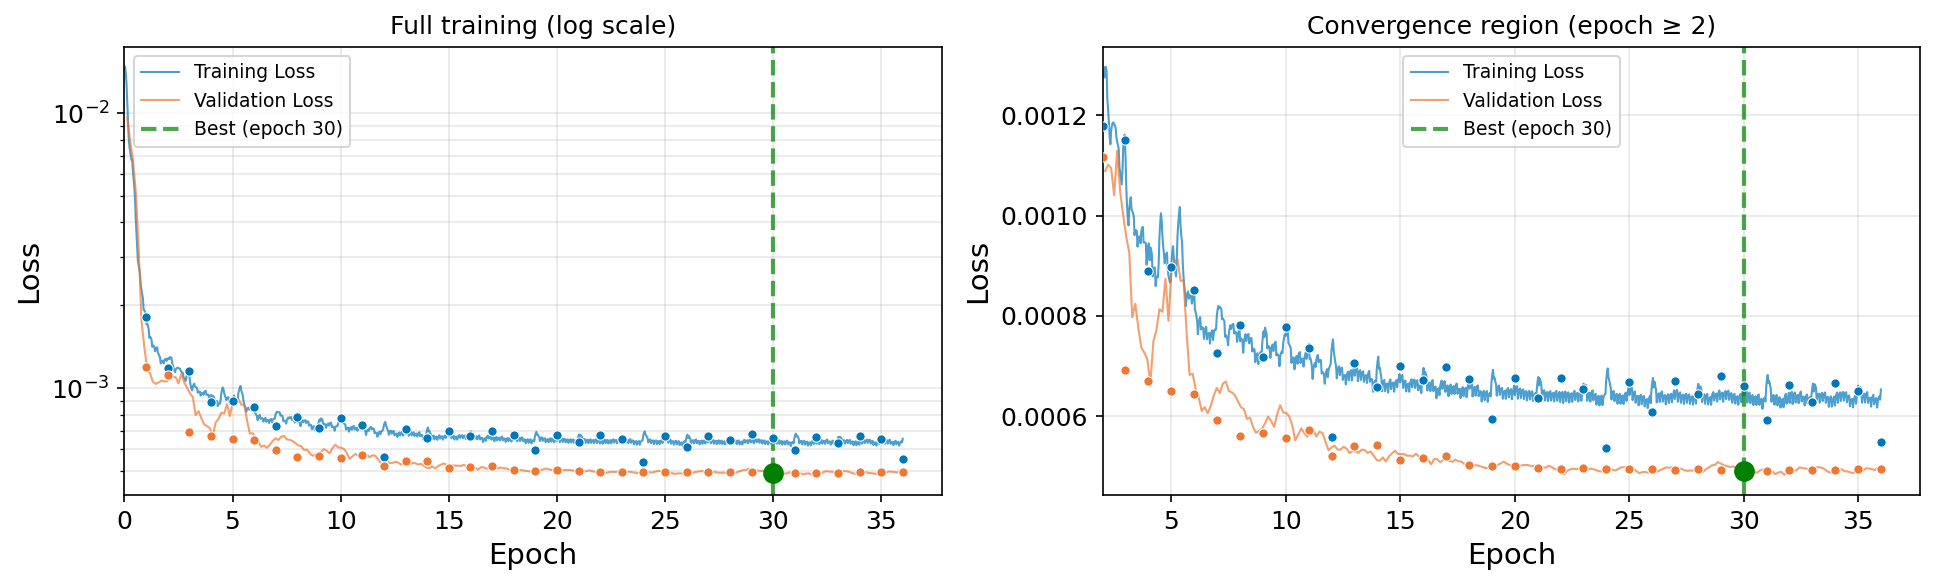

>> Position model: best epoch 30, val_loss=0.000492


In [17]:
# Plot POSITION training history (sub-epoch resolution)
def _rolling(y, w=4):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 2: return y
    cs = np.concatenate(([0.0], np.cumsum(y)))
    half = w // 2
    idx = np.arange(n)
    lo = np.maximum(0, idx - half)
    hi = np.minimum(n, idx + half + 1)
    return (cs[hi] - cs[lo]) / (hi - lo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epoch_val = pos_history.history['val_loss']
epoch_tr  = pos_history.history['loss']
n_epochs  = len(epoch_val)
best_epoch = np.argmin(epoch_val)
best_val_loss = epoch_val[best_epoch]

# ── Left panel: full view, log scale ──────────────────────────────────────────
if len(sub_epoch_logger.train_log) > 0:
    tr_epochs, tr_loss = zip(*sub_epoch_logger.train_log)
    tr_loss = _rolling(tr_loss)
    ax1.plot(tr_epochs, tr_loss, color=C_PRIMARY, linewidth=1.0, alpha=0.7, label='Training Loss')

if len(sub_epoch_logger.val_log) > 0:
    vl_epochs, vl_loss = zip(*sub_epoch_logger.val_log)
    vl_loss = _rolling(vl_loss)
    ax1.plot(vl_epochs, vl_loss, color=C_SECONDARY, linewidth=1.0, alpha=0.7, label='Validation Loss')

ax1.scatter(range(1, n_epochs+1), epoch_tr,  color=C_PRIMARY,   s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax1.scatter(range(1, n_epochs+1), epoch_val, color=C_SECONDARY, s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax1.axvline(x=best_epoch+1, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch+1})')
ax1.scatter([best_epoch+1], [best_val_loss], color='green', s=80, zorder=5)

ax1.set_yscale('log')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Full training (log scale)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(left=0)

# ── Right panel: convergence zoom (skip transient, auto y-limits) ─────────────
SKIP_EPOCHS = 2  # skip initial transient for cleaner zoom

if len(sub_epoch_logger.train_log) > 0:
    tr_e, tr_l = np.array(tr_epochs), np.array(tr_loss)
    mask_tr = tr_e >= SKIP_EPOCHS
    if mask_tr.any():
        ax2.plot(tr_e[mask_tr], tr_l[mask_tr], color=C_PRIMARY, linewidth=1.0, alpha=0.7, label='Training Loss')

if len(sub_epoch_logger.val_log) > 0:
    vl_e, vl_l = np.array(vl_epochs), np.array(vl_loss)
    mask_vl = vl_e >= SKIP_EPOCHS
    if mask_vl.any():
        ax2.plot(vl_e[mask_vl], vl_l[mask_vl], color=C_SECONDARY, linewidth=1.0, alpha=0.7, label='Validation Loss')

ep_range = range(max(SKIP_EPOCHS, 1), n_epochs+1)
ax2.scatter(list(ep_range), [epoch_tr[i-1] for i in ep_range],  color=C_PRIMARY,   s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax2.scatter(list(ep_range), [epoch_val[i-1] for i in ep_range], color=C_SECONDARY, s=20, zorder=4, edgecolors='white', linewidths=0.5)

ax2.axvline(x=best_epoch+1, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch+1})')
ax2.scatter([best_epoch+1], [best_val_loss], color='green', s=80, zorder=5)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title(f'Convergence region (epoch ≥ {SKIP_EPOCHS})')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(left=SKIP_EPOCHS)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/pos_training_history.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}/pos_training_history.pdf', bbox_inches='tight')
plt.show()

print(f">> Position model: best epoch {best_epoch+1}, val_loss={best_val_loss:.6f}")

### Quick bias check on the validation set
For each coordinate (X, Y, Z) compute the residual distribution (predicted − true, in cm) on the validation set and fit a Gaussian to it. The mean of the Gaussian is the **bias** and the standard deviation is the **resolution**. This is a fast sanity check to catch systematic offsets before the full evaluation.

In [18]:
# ── Quick position bias check on validation set (Gaussian fit per coordinate) ─
print(">> Position bias on validation set — Gaussian fit")

from scipy.optimize import curve_fit as _curve_fit

def _gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def _fit_gauss(diff, rng=150, nb=150):
    cnt, edges = np.histogram(diff, bins=nb, range=(-rng, rng))
    cx = (edges[:-1] + edges[1:]) / 2
    peak = cnt.max(); mu0 = cx[cnt.argmax()]
    ab = cx[cnt >= peak / 2]
    s0 = (ab[-1] - ab[0]) / 2.35 if len(ab) > 1 else 20.0
    try:
        popt, _ = _curve_fit(_gauss, cx, cnt, p0=[peak, mu0, s0],
                             bounds=([0, -rng, 0.5], [np.inf, rng, rng]), maxfev=5000)
        return popt[1], abs(popt[2])
    except Exception:
        return float(np.mean(diff)), float(np.std(diff))

_pred_norm = PosModel.predict(x_val, verbose=0)
_true_cm   = minmax_denormalize(y_val[:, :3])
_pred_cm   = minmax_denormalize(_pred_norm)
_diff      = _pred_cm - _true_cm   # Reco - True

print(f"\n   {'Coord':<6} {'μ (cm)':>10} {'σ (cm)':>10}")
print(f"   {'─'*28}")
for _i, _c in enumerate(['X', 'Y', 'Z']):
    _mu, _sig = _fit_gauss(_diff[:, _i])
    print(f"   {_c:<6} {_mu:>+10.2f} {_sig:>10.2f}")
print(f"\n   3D mean dist: {np.mean(np.linalg.norm(_diff, axis=1)):.1f} cm")

>> Position bias on validation set — Gaussian fit


2026-04-19 22:28:25.150196: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2748234160 exceeds 10% of free system memory.



   Coord      μ (cm)     σ (cm)
   ────────────────────────────
   X           -1.03       5.20
   Y           +0.11       6.56
   Z           -0.80       7.79

   3D mean dist: 17.8 cm


### Export the trained position model
Save the position model in TensorFlow SavedModel format for later inference, together with a JSON metadata file containing the normalization parameters (physical ranges, target ranges, normalization factor). The metadata is needed by the LArSoft C++ inference module to pre-process inputs and post-process outputs consistently with training.

In [21]:
# Export Position model for inference
import json
import gc

print('>> Exporting Position model for inference...')

def convert_numpy_types(obj):
    if isinstance(obj, np.ndarray):          return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)): return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):     return int(obj)
    elif isinstance(obj, dict):  return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):  return [convert_numpy_types(i) for i in obj]
    return obj

from datetime import datetime
date_str = datetime.now().strftime('%m%d')
n_events = len(y_train)
n_str    = f'{n_events//1000}k' if n_events >= 1000 else str(n_events)
base_export = f'{SAVE_DIR}/models/v{date_str}_trained_w_{n_str}'

pos_export_path   = base_export + '_position'
pos_model_save_path = os.path.join(pos_export_path, 'saved_model')
os.makedirs(pos_export_path, exist_ok=True)
PosModel.export(pos_model_save_path)

# ── Gaussian fit residuals on validation set (for performance section) ────
from scipy.optimize import curve_fit as _cfit
def _gauss(x, mu, sig, A): return A * np.exp(-0.5*((x-mu)/sig)**2)
def _fit_coord(pred_cm, true_cm):
    res = pred_cm - true_cm
    h, e = np.histogram(res, bins=200, range=(-100, 100))
    xc   = 0.5*(e[:-1]+e[1:])
    try:
        (mu, sig, _), _ = _cfit(_gauss, xc, h, p0=[0, 10, h.max()], maxfev=5000)
        return float(mu), abs(float(sig))
    except Exception:
        return float(np.mean(res)), float(np.std(res))

y_val_pred = PosModel.predict(x_val, verbose=0)
_scale = {k: (TARGET_RANGES[k][1]-TARGET_RANGES[k][0]) / (PHYS_RANGES[k][1]-PHYS_RANGES[k][0])
          for k in ['x','y','z']}
_phys_pred_val = np.column_stack([
    (y_val_pred[:, 0] / _scale['x']) + PHYS_RANGES['x'][0],
    (y_val_pred[:, 1] - TARGET_RANGES['y'][0]) / _scale['y'] + PHYS_RANGES['y'][0],
    (y_val_pred[:, 2] / _scale['z']) + PHYS_RANGES['z'][0],
])
_phys_true_val = np.column_stack([
    (y_val[:, 0] / _scale['x']) + PHYS_RANGES['x'][0],
    (y_val[:, 1] - TARGET_RANGES['y'][0]) / _scale['y'] + PHYS_RANGES['y'][0],
    (y_val[:, 2] / _scale['z']) + PHYS_RANGES['z'][0],
])
_d3d_val  = np.sqrt(np.sum((_phys_pred_val - _phys_true_val)**2, axis=1))
_bias_x_val, _sig_x_val = _fit_coord(_phys_pred_val[:,0], _phys_true_val[:,0])
_bias_y_val, _sig_y_val = _fit_coord(_phys_pred_val[:,1], _phys_true_val[:,1])
_bias_z_val, _sig_z_val = _fit_coord(_phys_pred_val[:,2], _phys_true_val[:,2])

pos_config = {
    'normalization': {
        'type': 'minmax',
        'pe_normalization_factor': float(normalization_factor),
        'note_pe': 'divide raw PE image by pe_normalization_factor before passing to the network',
        'ranges':       {k: list(v) for k, v in PHYS_RANGES.items()},
        'target_ranges':{k: list(v) for k, v in TARGET_RANGES.items()},
        'note_coords': 'apply inverse minmax to network output to recover x_abs (cm); x_abs is |x| — TPC side reconstructed separately',
    },
    'model': {
        'architecture': 'ResNet-18 (reduced, half filters: 32->64->128->256)',
        'n_params_approx': '2.8M',
        'input_shape': list(x_train.shape[1:]),
        'input_channels': ['uncoated PMT image', 'coated PMT image'],
        'output_shape': 3,
        'output_labels': ['x_abs', 'y', 'z'],
        'loss_function': 'MSE',
        'optimizer': 'AdamW',
    },
    'training_events':         len(y_train),
    'validation_events':       len(y_val),
    'best_val_loss_mse_scaled': float(min(pos_history.history['val_loss'])),
    'performance': {
        'validation': {
            'mean_3d_dist_cm': round(float(np.mean(_d3d_val)), 2),
            'x_bias_cm': round(_bias_x_val, 2), 'x_sigma_cm': round(_sig_x_val, 2),
            'y_bias_cm': round(_bias_y_val, 2), 'y_sigma_cm': round(_sig_y_val, 2),
            'z_bias_cm': round(_bias_z_val, 2), 'z_sigma_cm': round(_sig_z_val, 2),
        },
    },
}
pos_config_file = os.path.join(pos_export_path, 'inference_config.json')
with open(pos_config_file, 'w') as f:
    json.dump(convert_numpy_types(pos_config), f, indent=2)

print('   * Position model exported to:', pos_export_path)
print('   * Normalization: min-max with ranges', PHYS_RANGES)
print('   * Validation mean 3D dist: {:.1f} cm'.format(np.mean(_d3d_val)))


>> Exporting Position model for inference...
INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_position/saved_model/assets


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_position/saved_model/assets


Saved artifact at '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_position/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 59, 70, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140080450415680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079606464576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140080481356960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079606057792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079606062016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079606069936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079606469856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079606469328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079606470384: TensorS

### Direction Training

### Train the direction model
Same training procedure as the position model but with:
- **2D YZ output** (`dirY`, `dirZ`) — direction projected onto the plane perpendicular to the drift axis.
- **Sign-invariant angular loss** — penalizes the angle between the predicted and true direction, treating a vector and its opposite as equally valid.
- **Per-event cosine weights** to down-weight events where the true direction is nearly along the X axis (where the YZ projection carries little information).

In [22]:
# =============================================================================
# TRAINING 2: DIRECTION MODEL (reduced ResNet-18, 2D YZ, sign-invariant angular loss)
# =============================================================================
print("=" * 60)
print("   TRAINING 2: DIRECTION MODEL (reduced ResNet-18, 2D YZ)")
print("=" * 60)

import os
import numpy as np
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

DIR_CONFIG = {
    'epochs': 40,
    'batch_size': 128,
    'patience': 6,
    'min_lr': 1e-7,
    'dropout_rate': 0.3,
    'learning_rate': 3e-4,
    'LRpatience': 5,
    'warmup_epochs': 2,
}

print(f"   * Epochs: {DIR_CONFIG['epochs']}")
print(f"   * Batch size: {DIR_CONFIG['batch_size']}")
print(f"   * Patience: {DIR_CONFIG['patience']}")
print(f"   * LR: {DIR_CONFIG['learning_rate']}")
print(f"   * Loss: Angular loss (angle in radians, weighted by dEspread elongation)")
print(f"   * Dropout: {DIR_CONFIG['dropout_rate']}")

# Separate direction targets (2D: columns 3-4)
y_train_dir = y_train[:, 3:5]
y_val_dir = y_val[:, 3:5]
print(f"\n   * Train: {y_train_dir.shape}, Val: {y_val_dir.shape}")

# Extract directionality weights (column 5)
w_train_dir = y_train[:, 5]
w_val_dir   = y_val[:, 5]
print(f"   * Direction weights: train mean={np.mean(w_train_dir):.3f}, val mean={np.mean(w_val_dir):.3f}")

# Clean old checkpoint
dir_weights_file = '/tmp/weights_dir_model.keras'
if os.path.exists(dir_weights_file):
    os.remove(dir_weights_file)

# input_shape from training data (in case position model cell was not run)
input_shape = x_train.shape[1:]
print(f"   * Input shape: {input_shape}")

# Create direction model
DirModel = create_direction_model(input_shape, DIR_CONFIG['dropout_rate'])
print(f"   * Parameters: {DirModel.count_params():,}")

# Linear warmup scheduler (same WarmupScheduler class from position cell)
steps_per_epoch_dir = int(np.ceil(len(y_train_dir) / DIR_CONFIG['batch_size']))
warmup_steps_dir = steps_per_epoch_dir * DIR_CONFIG['warmup_epochs']
print(f"   * Steps/epoch: {steps_per_epoch_dir}, warmup steps: {warmup_steps_dir}")

warmup_cb_dir = WarmupScheduler(
    target_lr=DIR_CONFIG['learning_rate'],
    warmup_steps=warmup_steps_dir)

# Sub-epoch logger for direction (same class as position model)
sub_epoch_logger_dir = SubEpochLogger(
    val_data=(x_val, y_val_dir),
    log_every=50, val_every=200, val_samples=8192,
    val_weights=w_val_dir)

# Callbacks
dir_callbacks = [
    warmup_cb_dir,
    ModelCheckpoint(dir_weights_file, monitor='val_loss', verbose=1,
                    save_best_only=True, mode='min'),
    EarlyStopping(monitor='val_loss', patience=DIR_CONFIG['patience'],
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=DIR_CONFIG['LRpatience'],
                      min_lr=DIR_CONFIG['min_lr'], verbose=1),
    sub_epoch_logger_dir,
]

# Compile — clipnorm=1.0 kept for direction model: angular_loss uses arccos
# whose gradients can spike near domain boundaries (|dot| ~ 1)
DirModel.compile(
    optimizer=AdamW(learning_rate=1e-7,
                    weight_decay=1e-4, clipnorm=1.0),
    loss=angular_loss
)

# Train
print("\n>> Starting DIRECTION training...")
dir_history = DirModel.fit(
    x_train, y_train_dir,
    sample_weight=w_train_dir,
    epochs=DIR_CONFIG['epochs'],
    batch_size=DIR_CONFIG['batch_size'],
    callbacks=dir_callbacks,
    validation_data=(x_val, y_val_dir, w_val_dir),
    verbose=1,
    shuffle=True
)

print("\n>> Direction training completed!")
best_epoch_dir = np.argmin(dir_history.history['val_loss'])
print(f"   * Best epoch: {best_epoch_dir + 1}")
print(f"   * Best val_loss: {dir_history.history['val_loss'][best_epoch_dir]:.6f} rad")
print(f"   * Best val_loss: {np.degrees(dir_history.history['val_loss'][best_epoch_dir]):.2f} deg")
print(f"   * Sub-epoch points: {len(sub_epoch_logger_dir.train_log)} train, {len(sub_epoch_logger_dir.val_log)} val")

   TRAINING 2: DIRECTION MODEL (reduced ResNet-18, 2D YZ)
   * Epochs: 40
   * Batch size: 128
   * Patience: 6
   * LR: 0.0003
   * Loss: Angular loss (angle in radians, weighted by dEspread elongation)
   * Dropout: 0.3

   * Train: (388169, 2), Val: (83179, 2)
   * Direction weights: train mean=1.000, val mean=1.001
   * Input shape: (59, 70, 2)
   * Parameters: 2,835,266
   * Steps/epoch: 3033, warmup steps: 6066

>> Starting DIRECTION training...
Epoch 1/40
3033/3033 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5837
Epoch 1: val_loss improved from None to 0.52660, saving model to /tmp/weights_dir_model.keras
3033/3033 ━━━━━━━━━━━━━━━━━━━━ 94s 25ms/step - loss: 0.5022 - val_loss: 0.5266 - learning_rate: 1.5000e-04
Epoch 2/40
3031/3033 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5600
Epoch 2: val_loss did not improve from 0.52660
3033/3033 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - loss: 0.5333 - val_loss: 0.5289 - learning_rate: 3.0000e-04
Epoch 3/40
3030/3033 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms

### Display direction model architecture
Print the layer summary of the direction ResNet-18, analogous to the position model summary above.

In [23]:
# Direction model summary (rebuilt from definition for display)
_tmp_dir = create_direction_model((59, 70, 2), dropout_rate=0.3)
_tmp_dir.summary()
del _tmp_dir

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 59, 70, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 30, 35,    │      3,136 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 35,    │        128 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_51 (ReLU)     │ (None, 30, 35,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 15, 18,    │          0 │ re_lu_51[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 15, 18,    │      9,216 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_61[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_52 (ReLU)     │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_52[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_53 (ReLU)     │ (None, 15, 18,    │          0 │ add_24[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_53[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_54 (ReLU)     │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_54[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_64[0][0] 

 Total params: 2,835,266 (10.82 MB)

 Trainable params: 2,830,466 (10.80 MB)

 Non-trainable params: 4,800 (18.75 KB)

### Plot direction training history
Visualize training and validation angular loss versus epoch for the direction model, with rolling average smoothing and learning-rate panel. Same layout as the position plot for easy comparison.

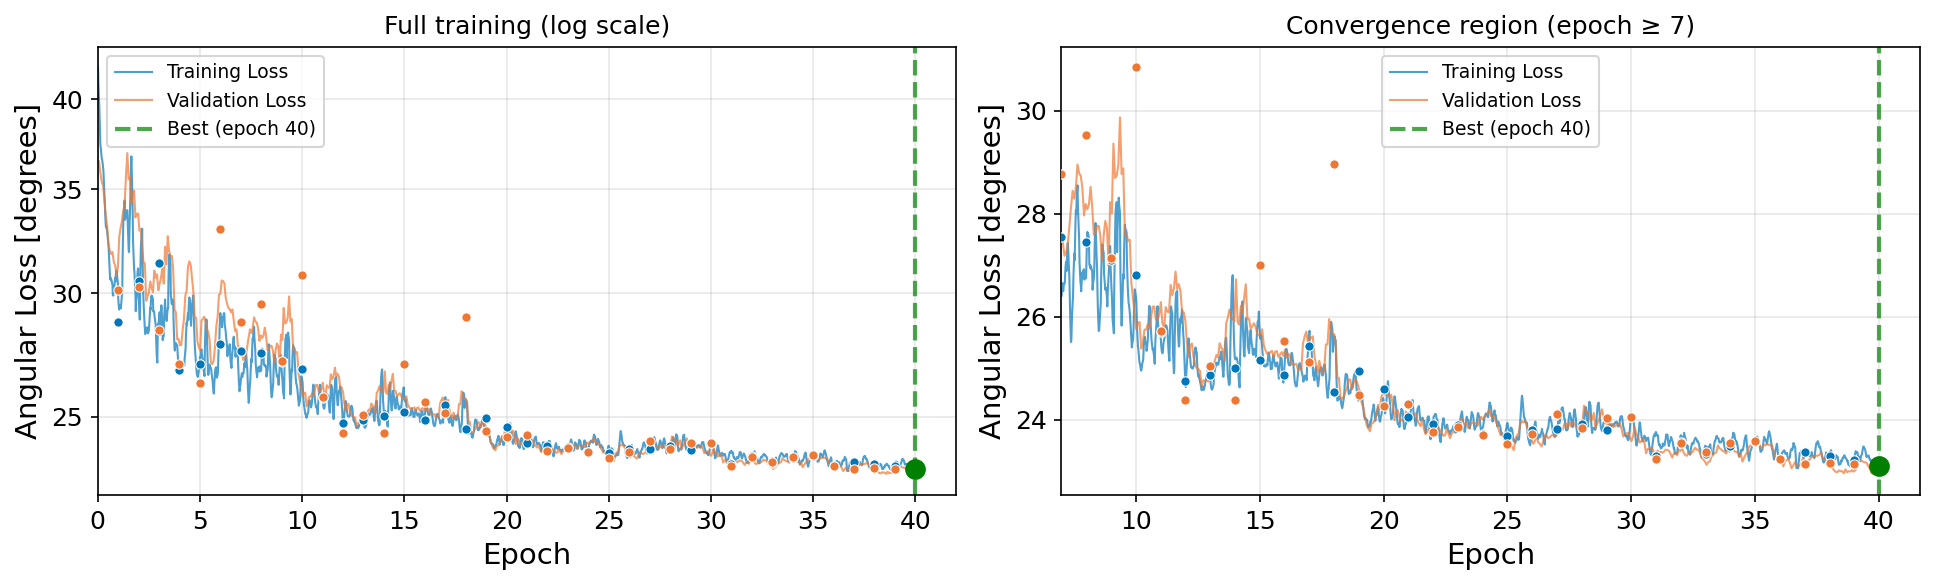

>> Direction model: best epoch 40, val_loss=23.11 deg


In [24]:
# Plot DIRECTION training history (sub-epoch resolution, mirrors position plot)
from matplotlib.ticker import FixedLocator, FuncFormatter

def _rolling(y, w=6):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 2: return y
    cs = np.concatenate(([0.0], np.cumsum(y)))
    half = w // 2
    idx = np.arange(n)
    lo = np.maximum(0, idx - half)
    hi = np.minimum(n, idx + half + 1)
    return (cs[hi] - cs[lo]) / (hi - lo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epoch_val_d = np.degrees(dir_history.history['val_loss'])
epoch_tr_d  = np.degrees(dir_history.history['loss'])
n_epochs_d  = len(epoch_val_d)
best_epoch_dir = int(np.argmin(epoch_val_d))
best_val_dir   = epoch_val_d[best_epoch_dir]

# ── Left panel: full view, log scale ─────────────────────────────────────
if len(sub_epoch_logger_dir.train_log) > 0:
    tr_e_d, tr_l_d = zip(*sub_epoch_logger_dir.train_log)
    tr_e_d = np.array(tr_e_d)
    tr_l_d = _rolling(np.degrees(tr_l_d))
    ax1.plot(tr_e_d, tr_l_d, color=C_PRIMARY, linewidth=1.0, alpha=0.7, label='Training Loss')

if len(sub_epoch_logger_dir.val_log) > 0:
    vl_e_d, vl_l_d = zip(*sub_epoch_logger_dir.val_log)
    vl_e_d = np.array(vl_e_d)
    vl_l_d = _rolling(np.degrees(vl_l_d))
    ax1.plot(vl_e_d, vl_l_d, color=C_SECONDARY, linewidth=1.0, alpha=0.7, label='Validation Loss')

ax1.scatter(range(1, n_epochs_d+1), epoch_tr_d,  color=C_PRIMARY,   s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax1.scatter(range(1, n_epochs_d+1), epoch_val_d, color=C_SECONDARY, s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax1.axvline(x=best_epoch_dir+1, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch_dir+1})')
ax1.scatter([best_epoch_dir+1], [best_val_dir], color='green', s=80, zorder=5)

ax1.set_yscale('log')
ax1.yaxis.set_major_locator(FixedLocator([20, 25, 30, 35, 40, 45, 50]))
ax1.yaxis.set_minor_locator(FixedLocator([]))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Angular Loss [degrees]')
ax1.set_title('Full training (log scale)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(left=0)

# ── Right panel: convergence zoom (skip transient, auto y-limits) ─────────────
SKIP_EPOCHS = 7  # skip plateau + warmup transient for cleaner zoom

if len(sub_epoch_logger_dir.train_log) > 0:
    mask_tr = tr_e_d >= SKIP_EPOCHS
    if mask_tr.any():
        ax2.plot(tr_e_d[mask_tr], tr_l_d[mask_tr], color=C_PRIMARY, linewidth=1.0, alpha=0.7, label='Training Loss')

if len(sub_epoch_logger_dir.val_log) > 0:
    mask_vl = vl_e_d >= SKIP_EPOCHS
    if mask_vl.any():
        ax2.plot(vl_e_d[mask_vl], vl_l_d[mask_vl], color=C_SECONDARY, linewidth=1.0, alpha=0.7, label='Validation Loss')

ep_range = range(max(SKIP_EPOCHS, 1), n_epochs_d+1)
ax2.scatter(list(ep_range), [epoch_tr_d[i-1] for i in ep_range],  color=C_PRIMARY,   s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax2.scatter(list(ep_range), [epoch_val_d[i-1] for i in ep_range], color=C_SECONDARY, s=20, zorder=4, edgecolors='white', linewidths=0.5)

ax2.axvline(x=best_epoch_dir+1, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch_dir+1})')
ax2.scatter([best_epoch_dir+1], [best_val_dir], color='green', s=80, zorder=5)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Angular Loss [degrees]')
ax2.set_title(f'Convergence region (epoch ≥ {SKIP_EPOCHS})')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(left=SKIP_EPOCHS)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/dir_training_history.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}/dir_training_history.pdf', bbox_inches='tight')
plt.show()

print(f">> Direction model: best epoch {best_epoch_dir+1}, val_loss={best_val_dir:.2f} deg")

## 8. Model Export


### Export both models
Save both models in SavedModel format alongside its metadata (coordinate config, normalization factor, date, dataset size). Both models are now ready for deployment in the LArSoft inference module.

In [25]:
# ========================================================================
# Export DIRECTION model
# ========================================================================
import json
from datetime import datetime
date_str = datetime.now().strftime('%m%d')
n_events = len(y_train)
n_str    = f'{n_events//1000}k' if n_events >= 1000 else str(n_events)
base_export = f'{SAVE_DIR}/models/v{date_str}_trained_w_{n_str}'

dir_export_path     = base_export + '_direction_2d'
dir_model_save_path = os.path.join(dir_export_path, 'saved_model')
os.makedirs(dir_export_path, exist_ok=True)
DirModel.export(dir_model_save_path)

# ── Angular error on validation set ──────────────────────────────────────
_dir_err_val = np.degrees(np.array(
    [float(v) for v in dir_history.history.get('val_loss', [min(dir_history.history['val_loss'])])]))
# Use direct prediction if available, else approximate from best val_loss
try:
    _dir_pred_val = DirModel.predict(x_val, verbose=0)
    _ynorm = _dir_pred_val[:,0] / np.linalg.norm(_dir_pred_val, axis=1)
    _znorm = _dir_pred_val[:,1] / np.linalg.norm(_dir_pred_val, axis=1)
    _ytrue = y_dir_val[:,0]
    _ztrue = y_dir_val[:,1]
    _dot   = np.clip(_ynorm*_ytrue + _znorm*_ztrue, -1.0, 1.0)
    _ang_err_deg_val = np.degrees(np.arccos(np.abs(_dot)))
    _mean_err_val    = round(float(np.mean(_ang_err_deg_val)),  2)
    _median_err_val  = round(float(np.median(_ang_err_deg_val)), 2)
except Exception:
    _mean_err_val   = round(float(np.degrees(min(dir_history.history['val_loss']))), 2)
    _median_err_val = None

dir_config = {
    'normalization': {
        'input': {
            'pe_normalization_factor': float(normalization_factor),
            'note': 'divide raw PE image by pe_normalization_factor before passing to the network',
        },
        'output': {
            'type': 'unit_vector_yz',
            'dir2d_y_range': [-1.0, 1.0],
            'dir2d_z_range': [0.0, 1.0],
            'note': 'network outputs (dirY, dirZ) projected onto YZ plane — renormalize to unit vector at inference, no coordinate inverse transform needed',
        },
    },
    'model': {
        'architecture': 'ResNet-18 (reduced, half filters: 32->64->128->256)',
        'n_params_approx': '2.8M',
        'input_shape': list(x_train.shape[1:]),
        'input_channels': ['uncoated PMT image', 'coated PMT image'],
        'output_shape': 2,
        'output_labels': ['dirY', 'dirZ'],
        'loss_function': 'angular_loss (atan2-based, sign-invariant)',
        'optimizer': 'AdamW',
    },
    'training_events':   len(y_train),
    'validation_events': len(y_val),
    'best_val_loss_rad': float(min(dir_history.history['val_loss'])),
    'best_val_loss_deg': float(np.degrees(min(dir_history.history['val_loss']))),
    'performance': {
        'validation': {
            'mean_error_deg':   _mean_err_val,
            'median_error_deg': _median_err_val,
        },
    },
}
config_file = os.path.join(dir_export_path, 'inference_config.json')
with open(config_file, 'w') as f:
    json.dump(dir_config, f, indent=2)

print('>> Direction model exported to:', dir_export_path)
print('   * Trained on {:,} events'.format(len(y_train)))
print('   * Best val_loss: {:.4f} rad = {:.2f} deg'.format(
    min(dir_history.history['val_loss']),
    np.degrees(min(dir_history.history['val_loss']))))


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_direction_2d/saved_model/assets


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_direction_2d/saved_model/assets


Saved artifact at '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_direction_2d/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 59, 70, 2), dtype=tf.float32, name='keras_tensor_140')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140079612615088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140088410403792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140080577810976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140080577812208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140088410399920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079612590064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079612577744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079612575984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140079612576864:

## 9. Inference


### Load saved models from disk
Reload the position and direction models from the SavedModel directories. This cell is useful when you want to run inference or evaluation without repeating the full training, e.g. in a separate session or after a kernel restart.

In [26]:

# ========================================================================
# Load saved models from disk (for inference without retraining)
# ========================================================================
import tensorflow as tf
import os

import glob as _glob
_pos_dirs = sorted(_glob.glob(f'{SAVE_DIR}/models/*_position/saved_model'))
_dir_dirs = sorted(_glob.glob(f'{SAVE_DIR}/models/*_direction_2d/saved_model'))
pos_model_path = _pos_dirs[-1] if _pos_dirs else None
dir_model_path = _dir_dirs[-1] if _dir_dirs else None
print(f">> Auto-detected model paths:")
print(f"   pos: {pos_model_path}")
print(f"   dir: {dir_model_path}")

def _make_predict_fn(model_path):
    """Load a SavedModel and return a predict(x) -> np.ndarray function."""
    raw = tf.saved_model.load(model_path)
    infer = raw.signatures['serving_default']
    # Get the input/output key names from the signature
    input_key  = list(infer.structured_input_signature[1].keys())[0]
    output_key = list(infer.structured_outputs.keys())[0]
    def predict(x):
        x_tensor = tf.constant(x, dtype=tf.float32)
        result = infer(**{input_key: x_tensor})
        return result[output_key].numpy()
    return predict

# --- Position model ---
if pos_model_path and os.path.exists(pos_model_path):
    _pos_predict_fn = _make_predict_fn(pos_model_path)
    class _PosWrapper:
        def predict(self, x): return _pos_predict_fn(x)
    PosModel = _PosWrapper()
    print(f">> Position model loaded from: {pos_model_path}")
    print(f"   * Input:  (N, 59, 70, 2)  |  Output: (N, 3) — (x, y, z scaled)")
else:
    print(f">> WARNING: position model not found at {pos_model_path}")
    print(f"   Using in-memory PosModel instead.")

# --- Direction model ---
if dir_model_path and os.path.exists(dir_model_path):
    _dir_predict_fn = _make_predict_fn(dir_model_path)
    class _DirWrapper:
        def predict(self, x): return _dir_predict_fn(x)
    DirModel = _DirWrapper()
    print(f">> Direction model loaded from: {dir_model_path}")
    print(f"   * Input:  (N, 59, 70, 2)  |  Output: (N, 2) — (dirY, dirZ)")
else:
    print(f">> WARNING: direction model not found at {dir_model_path}")
    print(f"   Using in-memory DirModel instead.")


>> Auto-detected model paths:
   pos: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_position/saved_model
   dir: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_direction_2d/saved_model
>> Position model loaded from: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_position/saved_model
   * Input:  (N, 59, 70, 2)  |  Output: (N, 3) — (x, y, z scaled)
>> Direction model loaded from: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_direction_2d/saved_model
   * Input:  (N, 59, 70, 2)  |  Output: (N, 2) — (dirY, dirZ)


### Define evaluation helper functions
Implement `evaluate_models`, which:
1. Runs the position and direction models on a given dataset split.
2. Denormalizes the predicted coordinates back to physical cm.
3. Fits Gaussians to the residual distributions for each coordinate.
4. Computes angular residuals for the direction model.
5. Produces summary plots (residual histograms, 2D bias maps).

The function is called identically for the validation set and the test set.

In [27]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import math

BIAS_RANGE  = 200   # cm (for Gaussian fit range)
BIAS_ZOOM   = 60    # cm (for plot x-axis)
NBINS       = 200

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fit_pos_residuals(diff, res_range=BIAS_RANGE, nbins=NBINS, n_sigma=2.5, n_iter=3, density=False):
    """Iterative Gaussian fit on the core of the residual distribution."""
    bins = np.linspace(-res_range, res_range, nbins + 1)
    cnt, edges = np.histogram(diff, bins=bins, density=density)
    cx = (edges[:-1] + edges[1:]) / 2
    peak  = cnt.max()
    mu0   = cx[cnt.argmax()]
    above = cx[cnt >= peak / 2]
    sig0  = (above[-1] - above[0]) / 2.35 if len(above) > 1 else 20.0
    popt = [peak, mu0, sig0]
    for _ in range(n_iter):
        mu_c, sig_c = popt[1], abs(popt[2])
        lo = max(mu_c - n_sigma * sig_c, -res_range)
        hi = min(mu_c + n_sigma * sig_c,  res_range)
        mask = (cx >= lo) & (cx <= hi) & (cnt > 0)
        if mask.sum() < 5:
            break
        try:
            popt, _ = curve_fit(gaussian, cx[mask], cnt[mask], p0=popt,
                                bounds=([0, -res_range, 0.1], [np.inf, res_range, res_range]),
                                maxfev=10000)
        except Exception:
            break
    return popt


def evaluate_models(x_data, y_data, set_label, save_prefix):
    """Full evaluation of position + direction models on a given dataset."""
    save_dir = SAVE_DIR

    # ── Predictions ───────────────────────────────────────────────────────────
    print(f">> Making predictions on {set_label.lower()} with both models...")
    pos_pred_norm  = PosModel.predict(x_data)
    pos_true_norm  = y_data[:, :3]
    dir2d_pred_raw = DirModel.predict(x_data)
    dir2d_true_raw = y_data[:, 3:5]

    dir2d_pred = dir2d_pred_raw / (np.linalg.norm(dir2d_pred_raw, axis=1, keepdims=True) + 1e-8)
    dir2d_true = dir2d_true_raw / (np.linalg.norm(dir2d_true_raw, axis=1, keepdims=True) + 1e-8)

    # Denormalize positions from [-1,1] back to physical cm
    pos_pred = minmax_denormalize(pos_pred_norm)
    pos_true = minmax_denormalize(pos_true_norm)

    N = len(x_data)
    pos_errors = pos_pred - pos_true
    dist_3d = np.linalg.norm(pos_errors, axis=1)

    cross = dir2d_true[:, 0] * dir2d_pred[:, 1] - dir2d_true[:, 1] * dir2d_pred[:, 0]
    dot   = np.sum(dir2d_true * dir2d_pred, axis=1)
    angle_err = np.degrees(np.arctan2(np.abs(cross), np.abs(dot)))

    print(f"   Predictions: {N:,} events")
    print(f"   Position  — mean 3D dist: {np.mean(dist_3d):.1f} cm")
    print(f"   Direction — median error:  {np.median(angle_err):.1f} deg")

    # ══════════════════════════════════════════════════════════════════════════
    # PLOT 1: Position (2x3) — Reco vs Truth (top) + Bias (bottom)
    # ══════════════════════════════════════════════════════════════════════════
    pos_names    = ['X', 'Y', 'Z']
    coord_units  = ['cm', 'cm', 'cm']
    coord_limits = [(0, 200), (-200, 200), (0, 500)]
    coord_bins   = [200, 200, 250]
    diff_pos     = pos_pred - pos_true

    fig, axs = plt.subplots(3, 3, figsize=(13, 11), constrained_layout=True)
    bias_results = {}

    for i, (coord, limits, nbins) in enumerate(zip(pos_names, coord_limits, coord_bins)):
        # ── Top: Reco vs Truth ────────────────────────────────────────────────
        ax = axs[0, i]
        hist, xe, ye = np.histogram2d(pos_true[:, i], pos_pred[:, i],
                                       bins=nbins, range=[limits, limits], density=True)
        exp  = int(math.floor(math.log10(hist.max()))) if hist.max() > 0 else 0
        scale = 10**exp
        hm = np.ma.masked_where(hist <= 0, hist / scale)
        im = ax.pcolormesh(xe, ye, hm.T, cmap=CMAP_2D, shading='auto',
                           norm=mcolors.PowerNorm(gamma=0.4))
        cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046,
                          label=r'Density [cm$^{-2}$]')
        cb.ax.set_title(f'1e{exp}', fontsize=FONT_TICK, pad=10)
        cb_max = float(hm.compressed().max()) if hm.count() > 0 else 1.0
        cb_ticks = np.linspace(cb_max / 4, cb_max, 4)
        cb.set_ticks(cb_ticks)
        cb.set_ticklabels([f'{t:.1f}' for t in cb_ticks])
        ax.plot(limits, limits, color=C_SECONDARY, lw=2.0, alpha=0.85)
        ax.set_xlim(limits); ax.set_ylim(limits)
        ax.set_xlabel(f'True {coord} [cm]', fontsize=FONT_LABEL)
        ax.set_ylabel(f'Reco {coord} [cm]', fontsize=FONT_LABEL)
        ax.tick_params(labelsize=FONT_TICK)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        # ── Middle: Reco-True vs True ─────────────────────────────────────────
        ax = axs[1, i]
        bias_range_2d = [(-BIAS_ZOOM, BIAS_ZOOM), (-BIAS_ZOOM, BIAS_ZOOM), (-BIAS_ZOOM*2, BIAS_ZOOM*2)]
        br = bias_range_2d[i]
        cnt2, xe2, ye2 = np.histogram2d(pos_true[:, i], diff_pos[:, i],
                                        bins=[nbins, 120],
                                        range=[limits, br])
        dx2 = xe2[1] - xe2[0]; dy2 = ye2[1] - ye2[0]
        h2 = cnt2 / (cnt2.sum() * dx2 * dy2)
        exp2  = int(math.floor(math.log10(h2.max()))) if h2.max() > 0 else 0
        hm2 = np.ma.masked_where((cnt2 < 4) | (h2 == 0), h2 / 10**exp2)
        im2 = ax.pcolormesh(xe2, ye2, hm2.T, cmap=CMAP_2D, shading='auto',
                            norm=mcolors.PowerNorm(gamma=0.4))
        cb2 = fig.colorbar(im2, ax=ax, pad=0.02, fraction=0.046, label=r'Density [cm$^{-2}$]')
        cb2.ax.set_title(f'1e{exp2}', fontsize=FONT_TICK, pad=10)
        cb2_max = float(hm2.compressed().max()) if hm2.count() > 0 else 1.0
        cb2.set_ticks(np.linspace(cb2_max/4, cb2_max, 4))
        cb2.set_ticklabels([f'{t:.1f}' for t in np.linspace(cb2_max/4, cb2_max, 4)])
        ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
        # Mean bias profile
        _edges = np.linspace(limits[0], limits[1], 21)
        _cx = (_edges[:-1] + _edges[1:]) / 2
        _mb = [diff_pos[(pos_true[:, i] >= _edges[j]) & (pos_true[:, i] < _edges[j+1]), i].mean()
               if ((pos_true[:, i] >= _edges[j]) & (pos_true[:, i] < _edges[j+1])).sum() > 50
               else np.nan for j in range(len(_edges)-1)]
        ax.plot(_cx, _mb, 'o-', color=C_SECONDARY, ms=3, lw=1.5, label='Mean bias')
        ax.set_xlabel(f'True {coord} [cm]', fontsize=FONT_LABEL)
        ax.set_ylabel(f'Reco $-$ True {coord} [cm]', fontsize=FONT_LABEL)
        ax.set_xlim(limits)
        ax.set_ylim(br)
        ax.tick_params(labelsize=FONT_TICK)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.legend(fontsize=FONT_STAT, framealpha=0.9)

        # ── Bottom: Bias ──────────────────────────────────────────────────────
        ax = axs[2, i]
        diff = diff_pos[:, i]
        popt = fit_pos_residuals(diff, density=True)
        mu, sig = popt[1], abs(popt[2])
        bias_results[coord] = {'mean': mu, 'sigma': sig}

        bins_z = np.linspace(-BIAS_ZOOM, BIAS_ZOOM, 121)
        ax.hist(diff, bins=bins_z, color=C_PRIMARY, edgecolor='none',
                density=True)
        x_fit = np.linspace(-BIAS_ZOOM, BIAS_ZOOM, 400)
        ax.plot(x_fit, gaussian(x_fit, popt[0], mu, sig), color=C_SECONDARY, lw=2.5)
        ax.axvline(0, color='k', ls='--', alpha=0.3, lw=0.8)
        ax.set_xlabel(f'Reco $-$ True {coord} [cm]', fontsize=FONT_LABEL)
        ax.set_ylabel('Density [cm$^{-1}$]', fontsize=FONT_LABEL)
        ax.set_xlim(-BIAS_ZOOM, BIAS_ZOOM)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        ax.tick_params(labelsize=FONT_TICK)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.text(0.96, 0.93,
            f'$\\mu$={mu:+.1f} cm\n$\\sigma$={sig:.1f} cm',
            transform=ax.transAxes, fontsize=FONT_STAT, va='top', ha='right',
            family='monospace', bbox=STAT_BOX)

    mse  = np.mean(pos_errors**2, axis=0)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(pos_errors), axis=0)

    plt.savefig(f'{save_dir}/{save_prefix}_pos_combined.png', dpi=SAVE_DPI, bbox_inches='tight')
    plt.savefig(f'{save_dir}/{save_prefix}_pos_combined.pdf', bbox_inches='tight')
    plt.show()

    print(f"   RMSE: X={rmse[0]:.1f}  Y={rmse[1]:.1f}  Z={rmse[2]:.1f} cm")
    print(f"   MAE:  X={mae[0]:.1f}  Y={mae[1]:.1f}  Z={mae[2]:.1f} cm")

    # ══════════════════════════════════════════════════════════════════════════
    # PLOT 2: Direction (1x3) — Beam angle | Error | Pred vs True
    # ══════════════════════════════════════════════════════════════════════════
    theta_true = np.degrees(np.arccos(np.clip(np.abs(dir2d_true[:, 1]), 0, 1)))
    theta_pred = np.degrees(np.arccos(np.clip(np.abs(dir2d_pred[:, 1]), 0, 1)))

    mean_ang   = np.mean(angle_err)
    med_ang    = np.median(angle_err)
    std_ang    = np.std(angle_err)
    p10        = 100*np.mean(angle_err < 10)
    p20        = 100*np.mean(angle_err < 20)

    fig, axs_d = plt.subplots(1, 3, figsize=(13, 4.0), constrained_layout=True)

    # ── Log-normal MLE (truncated on [0, 90]) — computed once, used in plot + summary
    from scipy import stats as _stats
    from scipy.optimize import minimize as _minimize
    from scipy.integrate import quad as _quad
    _ae = angle_err[(angle_err > 0) & (angle_err < 90)]
    def _neg_loglik(params):
        mu, sig = params
        if sig <= 0: return 1e10
        pdf_vals = _stats.lognorm.pdf(_ae, sig, scale=np.exp(mu))
        norm     = _stats.lognorm.cdf(90, sig, scale=np.exp(mu))
        if norm <= 0 or np.any(pdf_vals <= 0): return 1e10
        return -np.sum(np.log(pdf_vals / norm))
    _mu0, _sig0 = np.mean(np.log(_ae)), np.std(np.log(_ae), ddof=1)
    _res = _minimize(_neg_loglik, [_mu0, _sig0], method='Nelder-Mead',
                     options={'xatol':1e-5, 'fatol':1e-5, 'maxiter':5000})
    _mu_fit, _sig_fit = _res.x
    _norm_factor = _stats.lognorm.cdf(90, _sig_fit, scale=np.exp(_mu_fit))
    x_fit_ang = np.linspace(0.01, 90, 500)
    _pdf_fit = _stats.lognorm.pdf(x_fit_ang, _sig_fit, scale=np.exp(_mu_fit)) / _norm_factor
    _mean_ang, _ = _quad(lambda x: x * _stats.lognorm.pdf(x, _sig_fit, scale=np.exp(_mu_fit)) / _norm_factor, 0.001, 90)
    _ex2, _      = _quad(lambda x: x**2 * _stats.lognorm.pdf(x, _sig_fit, scale=np.exp(_mu_fit)) / _norm_factor, 0.001, 90)
    _std_ang = np.sqrt(_ex2 - _mean_ang**2)

    # ── Left: Angular error ───────────────────────────────────────────────────
    ax = axs_d[0]
    ax.hist(angle_err, bins=90, range=(0, 90),
            color=C_PRIMARY, edgecolor='none', density=True)
    ax.plot(x_fit_ang, _pdf_fit, color=C_SECONDARY, lw=2.5,
            label=f'LogNorm  mean={_mean_ang:.1f}°, std={_std_ang:.1f}°')
    ax.set_xlabel('Angular error [deg]', fontsize=FONT_LABEL)
    ax.set_ylabel('Density [deg$^{-1}$]', fontsize=FONT_LABEL)
    ax.set_xlim(0, 90)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.legend(fontsize=FONT_STAT, framealpha=0.9)
    ax.tick_params(labelsize=FONT_TICK)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    # ── Center: theta_z distribution ─────────────────────────────────────────
    ax = axs_d[1]
    ax.hist(theta_true, bins=90, range=(0, 90),
            color=C_PRIMARY, edgecolor='none', label='True', density=True)
    ax.hist(theta_pred, bins=90, range=(0, 90),
            color=C_SECONDARY, edgecolor=C_SECONDARY, label='Predicted', density=True, histtype='step', lw=1.8)
    ax.set_xlabel(r'$\theta_z$ [deg]', fontsize=FONT_LABEL)
    ax.set_ylabel('Density [deg$^{-1}$]', fontsize=FONT_LABEL)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlim(0, 90)
    ax.legend(fontsize=FONT_STAT, framealpha=1.0)
    ax.tick_params(labelsize=FONT_TICK)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    bm_t = 100*np.mean(theta_true < 30)
    bm_p = 100*np.mean(theta_pred < 30)
    ax.text(0.96, 0.93,
        f'<30\u00b0: True={bm_t:.0f}%  Pred={bm_p:.0f}%',
        transform=ax.transAxes, fontsize=FONT_STAT, va='top', ha='right',
        family='monospace', bbox=STAT_BOX)

    # ── Right: Pred vs True theta_z ───────────────────────────────────────────
    ax = axs_d[2]
    from scipy.ndimage import gaussian_filter
    h, xe, ye = np.histogram2d(theta_true, theta_pred, bins=90,
                               range=[(0,90),(0,90)], density=True)
    h_smooth = gaussian_filter(h, sigma=1.0)
    exp_d  = int(math.floor(math.log10(h_smooth.max()))) if h_smooth.max() > 0 else 0
    hm = np.ma.masked_where(h_smooth <= 0, h_smooth / 10**exp_d)
    im = ax.pcolormesh(xe, ye, hm.T, cmap=CMAP_2D, shading='auto',
                       norm=mcolors.PowerNorm(gamma=0.4))
    cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046,
                      label=r'Density [deg$^{-2}$]')
    cb.ax.set_title(f'1e{exp_d}', fontsize=FONT_TICK, pad=10)
    cb_max_d = float(hm.compressed().max()) if hm.count() > 0 else 1.0
    cb_ticks_d = np.linspace(cb_max_d / 4, cb_max_d, 4)
    cb.set_ticks(cb_ticks_d)
    cb.set_ticklabels([f'{t:.1f}' for t in cb_ticks_d])
    ax.plot([0,90], [0,90], color=C_SECONDARY, lw=2.0, alpha=1.0)
    ax.set_xlim(0, 90); ax.set_ylim(0, 90)
    ax.set_xlabel(r'True $\theta_z$ [deg]', fontsize=FONT_LABEL)
    ax.set_ylabel(r'Predicted $\theta_z$ [deg]', fontsize=FONT_LABEL)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=FONT_TICK)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    plt.savefig(f'{save_dir}/{save_prefix}_dir_combined.png', dpi=SAVE_DPI, bbox_inches='tight')
    plt.savefig(f'{save_dir}/{save_prefix}_dir_combined.pdf', bbox_inches='tight')
    plt.show()

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  {set_label.upper()} RESULTS  (N={N:,})")
    print(f"{'='*55}")
    print(f"  Position:")
    for c in pos_names:
        m, s = bias_results[c]['mean'], bias_results[c]['sigma']
        print(f"    {c}: bias={m:+.2f} cm, sigma={s:.2f} cm")
    print(f"  Direction:")
    print(f"    Mean={mean_ang:.1f}\u00b0  Median={med_ang:.1f}\u00b0  <10\u00b0:{p10:.0f}%  <20\u00b0:{p20:.0f}%")
    print(f"    LogNorm fit: mu={_mu_fit:.2f}, sigma={_sig_fit:.2f}  =>  mean={_mean_ang:.1f}\u00b0, std={_std_ang:.1f}\u00b0")
    print(f"{'='*55}")

    return {
        'bias_results': bias_results,
        'rmse': rmse,
        'mae': mae,
        'overall_rmse': float(np.sqrt(np.mean(dist_3d**2))),
        'dir_stats': {
            'mean': mean_ang, 'median': med_ang, 'std': std_ang,
            'pct_10': p10, 'pct_20': p20,
        },
    }

## 10. Model Evaluation on Validation Set


### Reload plot style
Re-import the custom matplotlib style module to ensure consistent colors, fonts, and figure sizes for the evaluation plots below.

In [28]:
import importlib, plot_style
importlib.reload(plot_style)
from plot_style import *

### Evaluate on the validation set
Run the full evaluation pipeline on the held-out **validation** set. The validation set was used during training (for early stopping and LR scheduling), so these results give an optimistic upper bound on generalization performance.

>> Making predictions on validation set with both models...


2026-04-19 23:16:53.920246: W tensorflow/core/kernels/gpu_utils.cc:68] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be printed once.


   Predictions: 83,179 events
   Position  — mean 3D dist: 17.8 cm
   Direction — median error:  15.0 deg


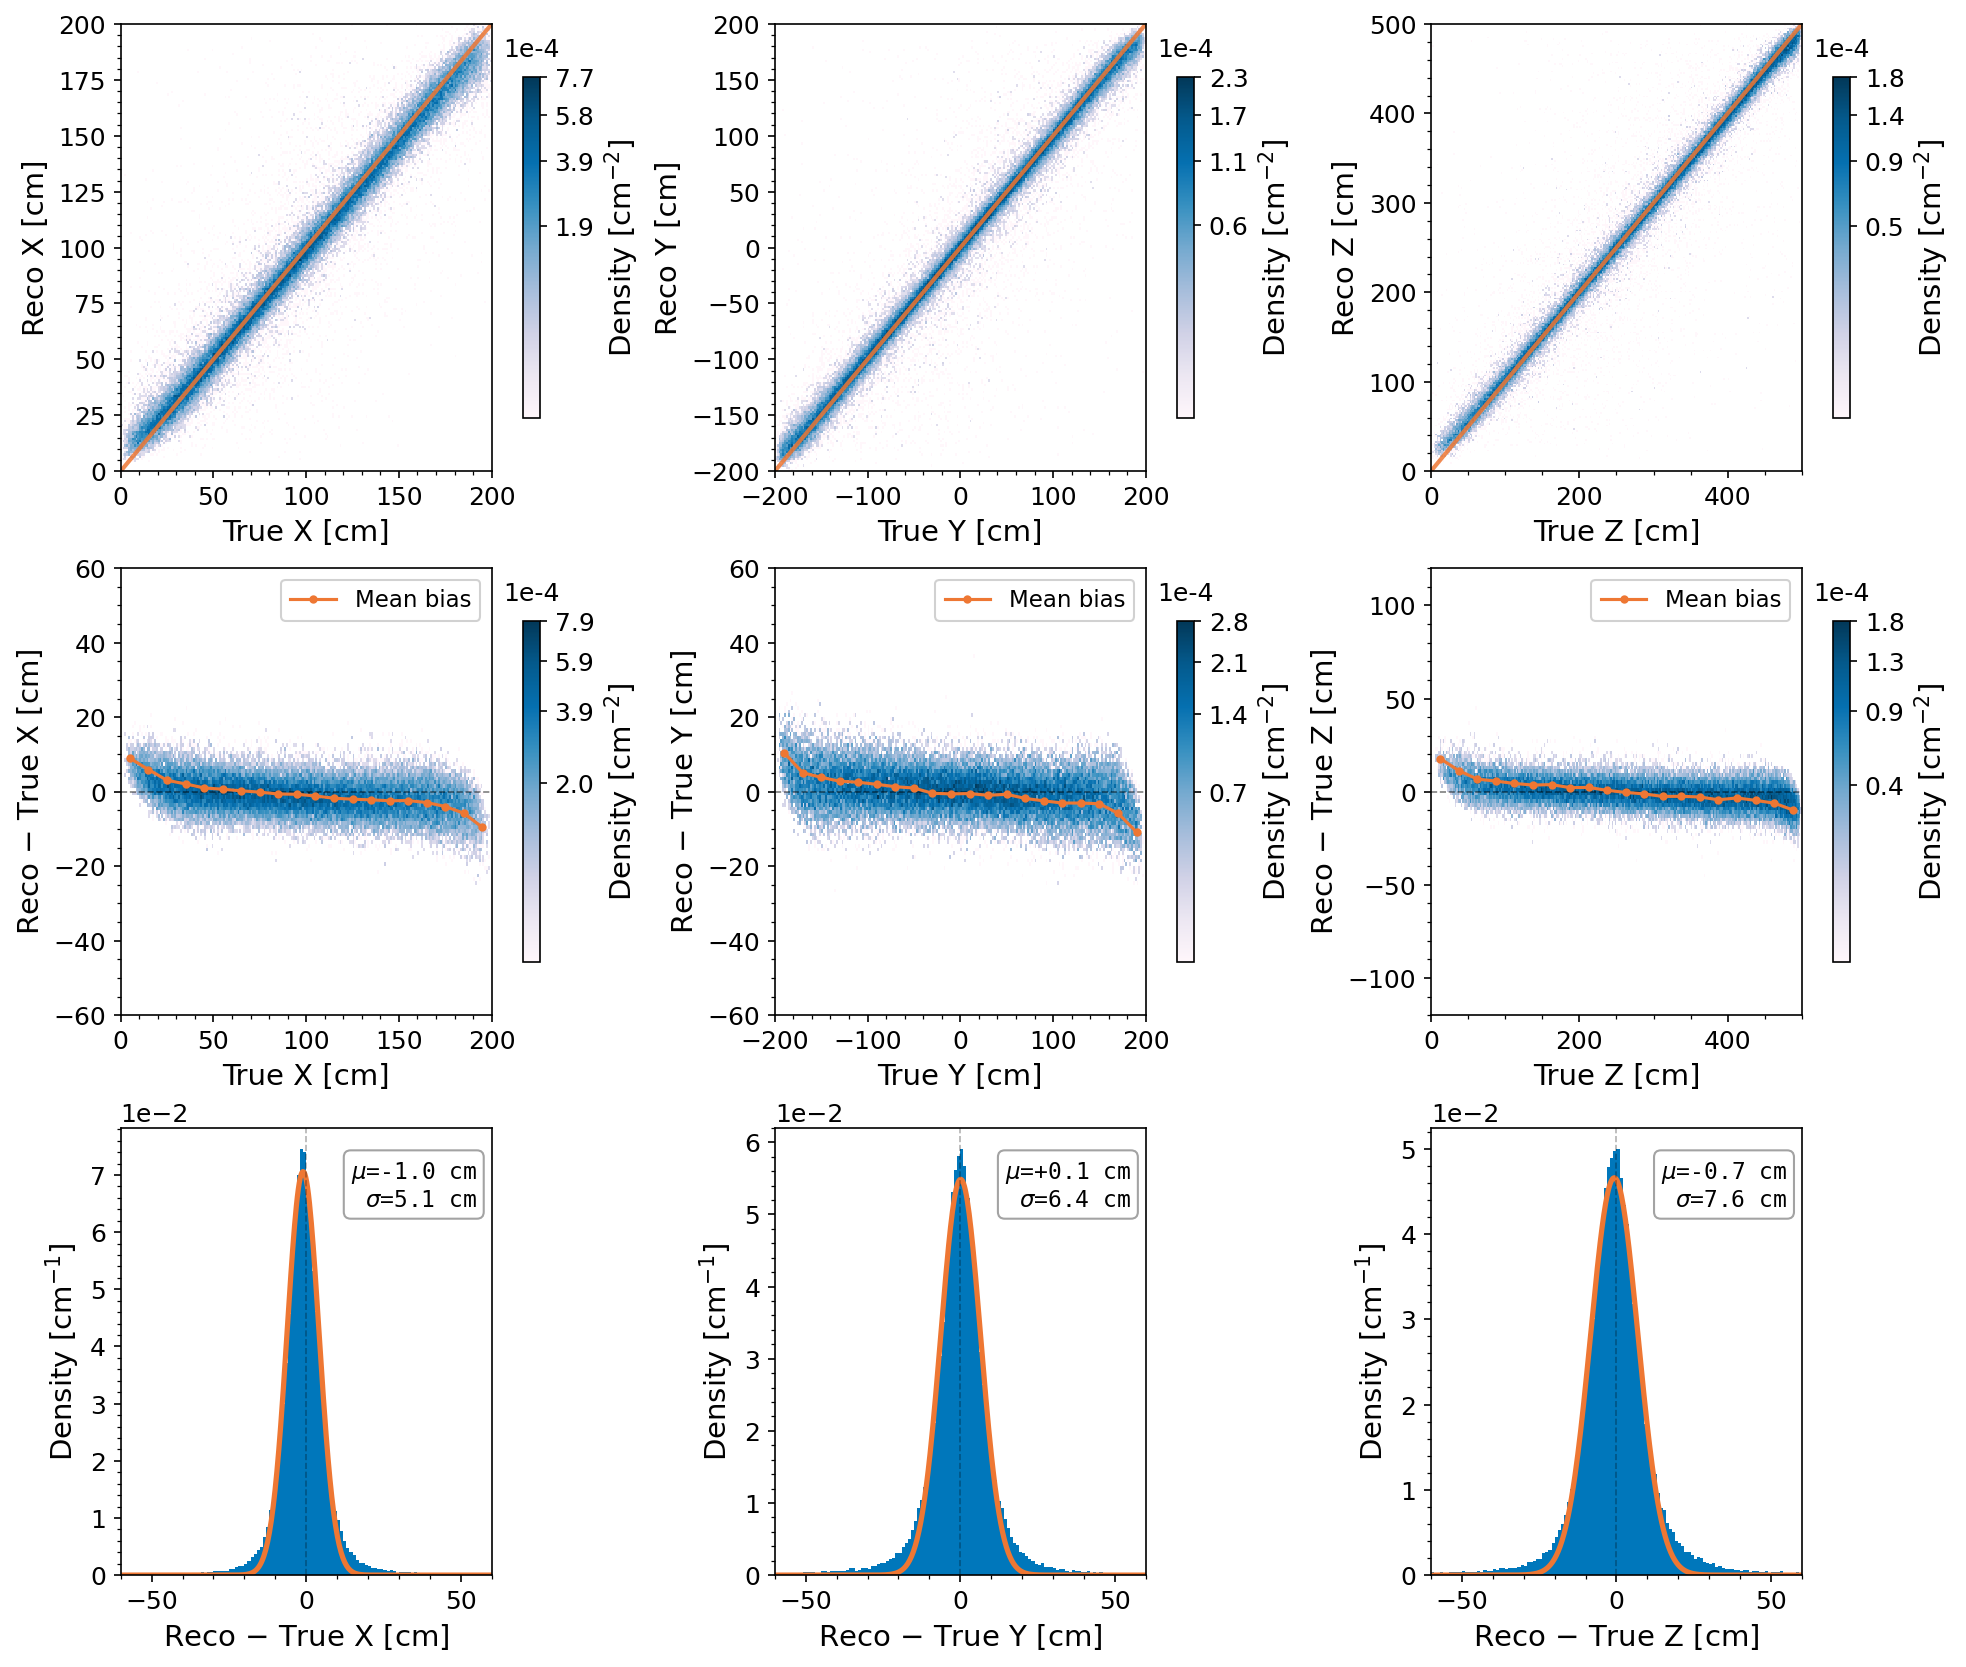

   RMSE: X=10.7  Y=18.7  Z=25.1 cm
   MAE:  X=6.1  Y=8.9  Z=11.1 cm


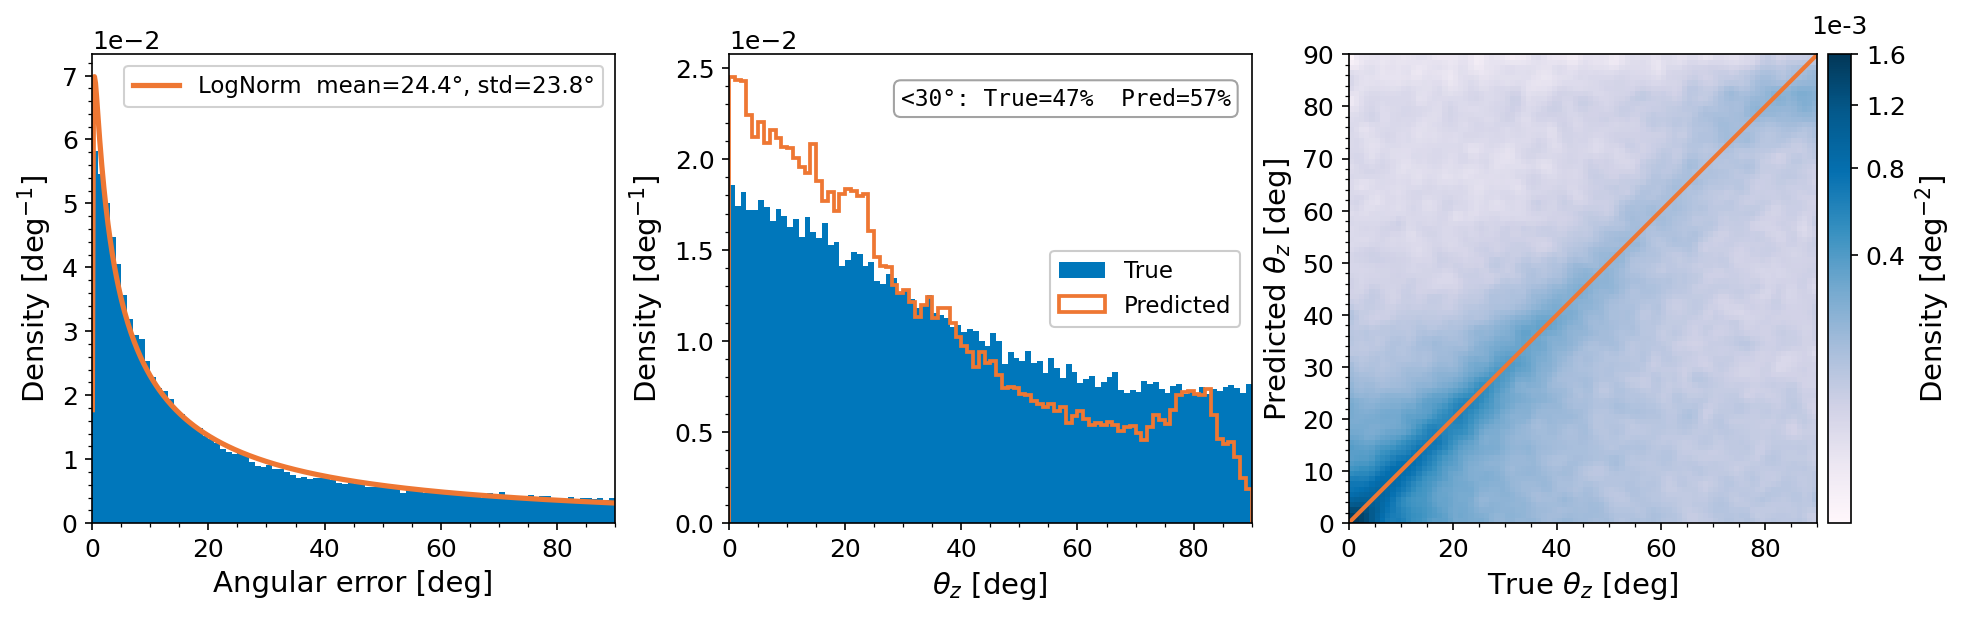


  VALIDATION SET RESULTS  (N=83,179)
  Position:
    X: bias=-1.01 cm, sigma=5.13 cm
    Y: bias=+0.11 cm, sigma=6.43 cm
    Z: bias=-0.70 cm, sigma=7.64 cm
  Direction:
    Mean=24.5°  Median=15.0°  <10°:40%  <20°:58%
    LogNorm fit: mu=3.85, sigma=2.20  =>  mean=24.4°, std=23.8°


In [29]:
# ── Run on validation set ─────────────────────────────────────────────────────
results_validation = evaluate_models(x_val, y_val, 'Validation Set', 'val')

## 11. Model Evaluation on Test Set


### Evaluate on the test set
Run the same evaluation on the completely held-out **test** set. Unlike the validation set, the test set was never seen during training or hyperparameter tuning, so these numbers are the unbiased estimate of the model's performance on new data.

>> Making predictions on test set with both models...
   Predictions: 83,180 events
   Position  — mean 3D dist: 17.7 cm
   Direction — median error:  15.0 deg


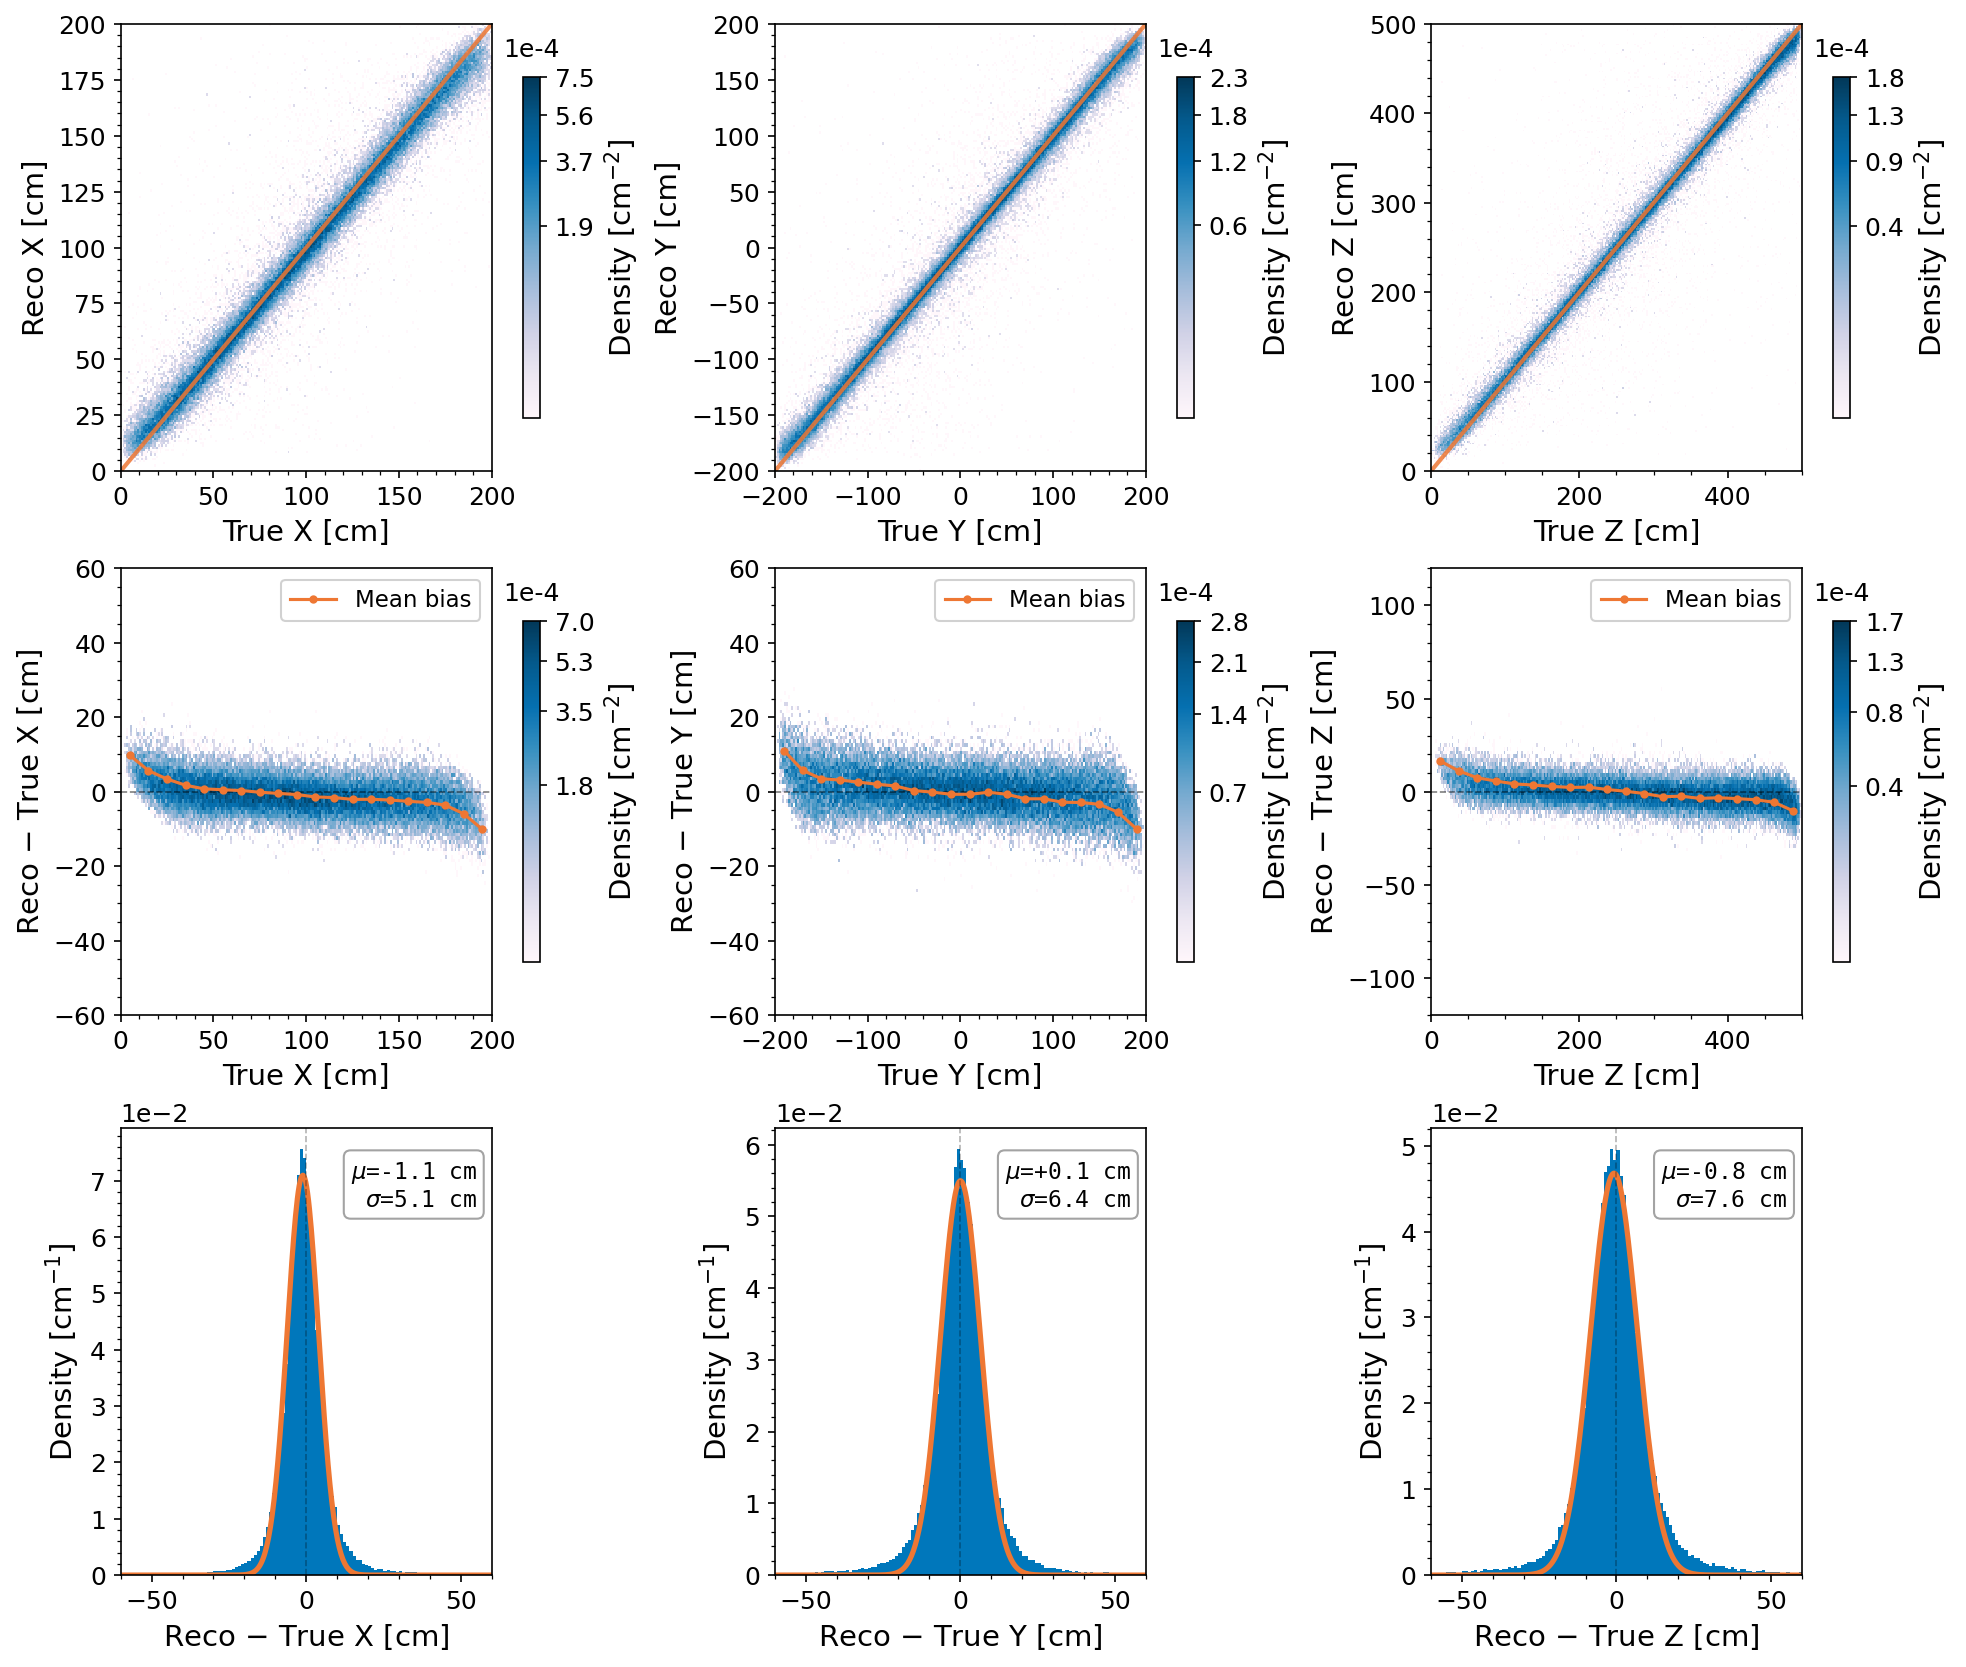

   RMSE: X=10.5  Y=18.2  Z=24.6 cm
   MAE:  X=6.0  Y=8.8  Z=11.0 cm


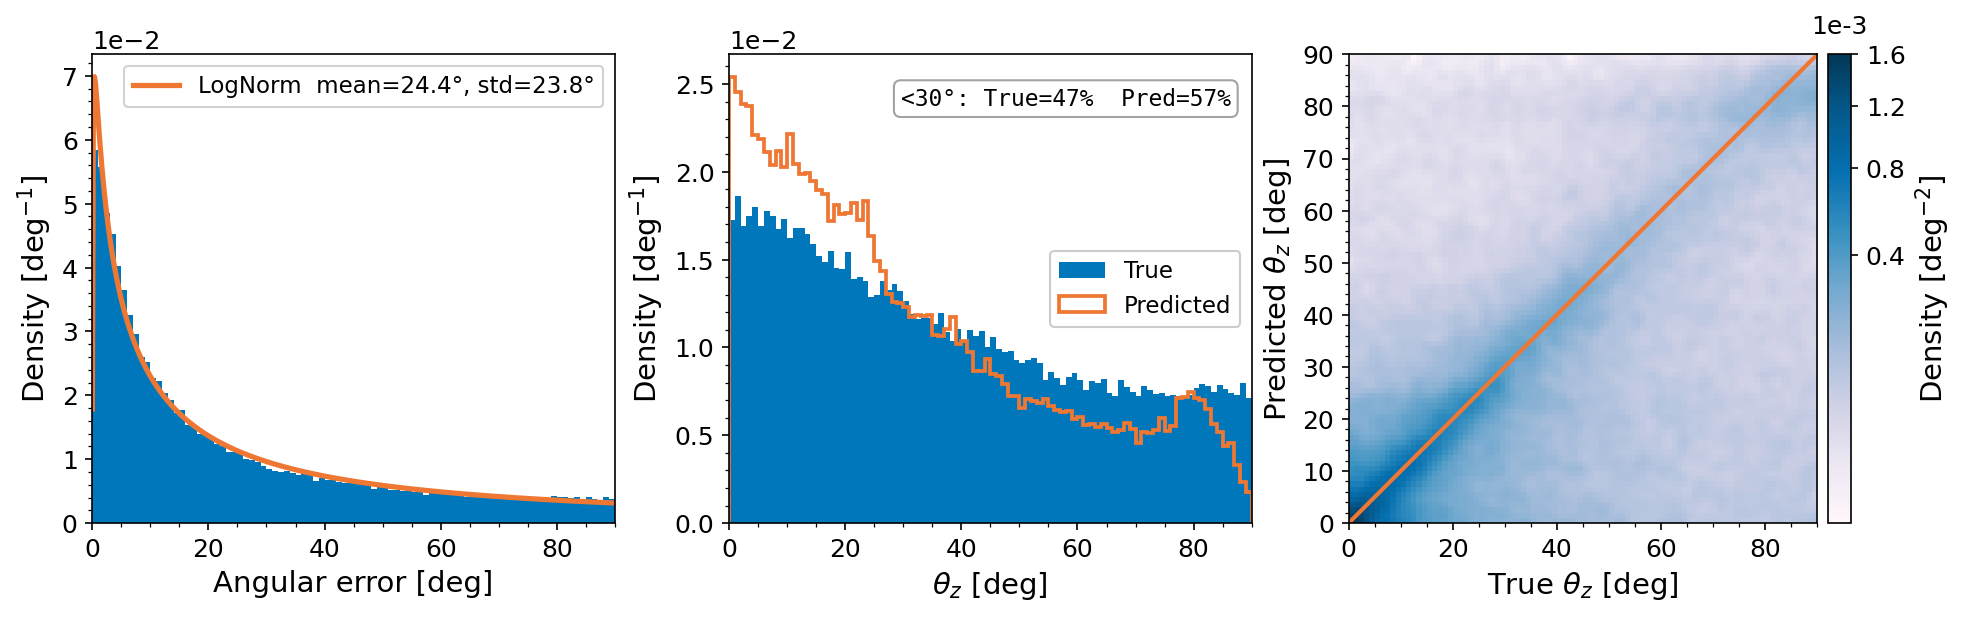


  TEST SET RESULTS  (N=83,180)
  Position:
    X: bias=-1.08 cm, sigma=5.09 cm
    Y: bias=+0.05 cm, sigma=6.45 cm
    Z: bias=-0.78 cm, sigma=7.60 cm
  Direction:
    Mean=24.5°  Median=15.0°  <10°:40%  <20°:58%
    LogNorm fit: mu=3.85, sigma=2.20  =>  mean=24.4°, std=23.8°


In [30]:
# ── Run on test set ────────────────────────────────────────────────────────────
results_test = evaluate_models(x_test_set, y_test_combined, 'Test Set', 'test')

## 12. Training Summary


### Print final training summary
Display a concise summary of the completed pipeline: dataset sizes, paths to the saved models, and the key performance metrics (bias and resolution per coordinate) for both validation and test sets.

In [31]:
print("=" * 60)
print("   TRAINING PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)

pos_names = ['X', 'Y', 'Z']

bias_results_val  = results_validation['bias_results']
bias_results_test = results_test['bias_results']

print(f"\n>> Dataset:")
print(f"   * Training events:   {len(y_train):,}")
print(f"   * Validation events: {len(y_val):,}")

print(f"\n>> Models saved:")
print(f"   * Position:  {pos_model_save_path}")
print(f"   * Direction: {dir_model_save_path}")

print(f"\n>> Validation performance:")
print(f"   * Final val loss (pos): {min(pos_history.history['val_loss']):.6f}")
print(f"   * Overall RMSE (3D):    {results_validation['overall_rmse']:.2f} cm")
for coord in pos_names:
    mean  = bias_results_val[coord]['mean']
    sigma = bias_results_val[coord]['sigma']
    print(f"   * {coord}: bias = {mean:+.2f} cm,  sigma = {sigma:.2f} cm")

print(f"\n>> Test performance:")
print(f"   * Overall RMSE (3D): {results_test['overall_rmse']:.2f} cm")
for coord in pos_names:
    mean  = bias_results_test[coord]['mean']
    sigma = bias_results_test[coord]['sigma']
    print(f"   * {coord}: bias = {mean:+.2f} cm,  sigma = {sigma:.2f} cm")

print(f"\n>> Direction (YZ plane, sign-invariant):")
print(f"   * Validation — mean: {results_validation['dir_stats']['mean']:.2f}°,  median: {results_validation['dir_stats']['median']:.2f}°")
print(f"   * Test        — mean: {results_test['dir_stats']['mean']:.2f}°,  median: {results_test['dir_stats']['median']:.2f}°")

# Clean up large arrays from memory
for _var in ['x_train', 'x_val', 'x_test_set', 'y_train', 'y_val', 'y_test_combined', 'images']:
    globals().pop(_var, None)
gc.collect()
print(f"\n>> Memory cleaned up")
print("=" * 60)


   TRAINING PIPELINE COMPLETED SUCCESSFULLY

>> Dataset:
   * Training events:   388,169
   * Validation events: 83,179

>> Models saved:
   * Position:  /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_position/saved_model
   * Direction: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_MC/run_20260419_2158/models/v0419_trained_w_388k_direction_2d/saved_model

>> Validation performance:
   * Final val loss (pos): 0.000492
   * Overall RMSE (3D):    33.13 cm
   * X: bias = -1.01 cm,  sigma = 5.13 cm
   * Y: bias = +0.11 cm,  sigma = 6.43 cm
   * Z: bias = -0.70 cm,  sigma = 7.64 cm

>> Test performance:
   * Overall RMSE (3D): 32.38 cm
   * X: bias = -1.08 cm,  sigma = 5.09 cm
   * Y: bias = +0.05 cm,  sigma = 6.45 cm
   * Z: bias = -0.78 cm,  sigma = 7.60 cm

>> Direction (YZ plane, sign-invariant):
   * Validation — mean: 24.45°,  median: 14.95°
   * Test        — mean: 24.48°